<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/IC_PROYECTO_FINAL/FSL_Vision_E2E_v7_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FSL-Vision — Pipeline End-to-End (v3.1 final)
**Trabajo Final Integrador — Inteligencia Computacional (IC415)**

v3.1 corrige la idempotencia de la descarga: cada recorte se nombra por el **uuid de su caja** (estable), así re-correr NO vuelve a bajar lo que ya tenés en Drive. Incluye recorte a bounding box, balanceo, tope de cajas/imagen (diversidad), split estratificado + agrupado, EfficientNet-B0, fine-tuning y diagnóstico.

> **Importante para esta corrida:** como cambió el esquema de nombres de archivo, conviene borrar `data/raw/` y `data/processed/` en Drive una vez y hacer una corrida limpia. A partir de ahí, re-correr la Celda 3 detecta todo y no descarga nada. Fases 2/2.5 requieren GPU (T4).

## Celda 1 — Preparación del Entorno

In [1]:
# === CELDA 1: Preparación del Entorno ===

# 1) Montar Google Drive (acá persiste TODO: dataset, manifiesto y reporte).
from google.colab import drive
drive.mount('/content/drive')

# 2) Instalar dependencias.
#    - fathomnet: cliente oficial de FathomNet (MBARI)
#    - pyyaml: lectura del archivo de configuración
#    - ydata-profiling: motor de AutoEDA
#    - scikit-learn: split estratificado (Celda 6)
#    - Pillow: control de integridad y recortes (Celdas 5 y 7)
!pip install -q fathomnet pyyaml ydata-profiling scikit-learn Pillow

# NOTA COLAB: si la Celda 4 falla al importar ydata_profiling, reiniciá la
# sesión ("Entorno de ejecución -> Reiniciar sesión") y re-corré desde la 1.

# 3) Rutas centralizadas (evita inconsistencias entre celdas).
import os
PROJECT_DIR     = "/content/drive/MyDrive/IC415"          # <-- tu carpeta en Drive
DATA_RAW        = os.path.join(PROJECT_DIR, "data", "raw")
DATA_PROCESSED  = os.path.join(PROJECT_DIR, "data", "processed")
CONFIG_PATH     = os.path.join(PROJECT_DIR, "paraense_fauna.yaml")
MANIFIESTO      = os.path.join(DATA_RAW, "manifiesto_dataset.csv")
MANIFIESTO_LIMPIO = os.path.join(DATA_RAW, "manifiesto_limpio.csv")
REPORTE_EDA     = os.path.join(DATA_RAW, "reporte_eda.html")

os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
print("Proyecto:", PROJECT_DIR)
print("Crudo ->", DATA_RAW)
print("Procesado ->", DATA_PROCESSED)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.4 MB/s eta 0:00:00
Proyecto: /content/drive/MyDrive/IC415
Crudo -> /content/drive/MyDrive/IC415/data/raw
Procesado -> /content/drive/MyDrive/IC415/data/processed


## Celda 2 — Configuración (paraense_fauna.yaml) — recorte + balance + tope de cajas/imagen

In [2]:
%%writefile /content/drive/MyDrive/IC415/paraense_fauna.yaml
# =====================================================================
# paraense_fauna.yaml  -  FSL-Vision Data Pipeline (v3)
# v3 agrega max_cajas_por_imagen para resolver el problema de Porifera:
# como las esponjas traen muchísimas cajas por foto (hasta 39), sus recortes
# salían de poquísimas escenas -> poca diversidad y un val diminuto tras el
# split agrupado. Topeando las cajas por imagen, los 400 recortes salen de
# muchas más fotos distintas.
# =====================================================================

descarga:
  proveedor_taxonomia: "fathomnet"   # expande cada concepto a sus descendientes
  solo_verificadas: false            # incluir NO verificadas -> volumen
  recorte_a_caja: true               # recortar al bounding box (quita el fondo confusor)
  objetivo_por_clase: 400            # meta de RECORTES por clase
  max_cajas_por_imagen: 3            # tope de recortes por foto -> diversidad de escenas
  min_lado_caja_px: 32               # descartar cajas diminutas (recortes ilegibles)
  pausa_segundos: 0.15
  reintentos: 3

conceptos:
  - {carpeta: "asteroidea", concepto: "Asteroidea"}
  - {carpeta: "scyphozoa",  concepto: "Scyphozoa"}
  - {carpeta: "porifera",   concepto: "Porifera"}
  - {carpeta: "octopoda",   concepto: "Octopoda"}


Overwriting /content/drive/MyDrive/IC415/paraense_fauna.yaml


## Celda 3 — Extracción FathomNet con recorte a Bounding Box + Manifiesto (idempotencia robusta)

In [3]:
# === CELDA 3: Extracción FathomNet con RECORTE a Bounding Box + Manifiesto ===
import os, csv, time, requests, yaml
from io import BytesIO
from PIL import Image
from fathomnet.api import images, taxa
from fathomnet.dto import GeoImageConstraints

HEADERS = {"User-Agent": "IC415-UNaM-FSL-Vision/1.0"}
PLATAFORMAS = ["Tiburon", "Ventana", "Doc Ricketts", "i2MAP", "MiniROV", "Hercules"]


def plataforma_desde_url(url):
    if not url:
        return None
    u = url.replace(" ", "")
    for p in PLATAFORMAS:
        if p.replace(" ", "") in u:
            return p
    return None


def conjunto_descendientes(concepto, provider):
    """Concepto + todos sus descendientes taxonómicos, para quedarnos SOLO con las
    cajas de NUESTRA clase e ignorar las de otras especies de la misma imagen."""
    nombres = {t.name for t in taxa.find_taxa(provider, concepto)}
    nombres.add(concepto)
    return nombres


def bajar_imagen(url, reintentos, pausa):
    """Descarga robusta -> objeto PIL en RAM (no guardamos el frame entero en disco)."""
    for intento in range(reintentos):
        try:
            r = requests.get(url, headers=HEADERS, timeout=30)
            r.raise_for_status()
            return Image.open(BytesIO(r.content)).convert("RGB")
        except Exception as e:
            if intento == reintentos - 1:
                print(f"   ! descarga fallida ({e})")
                return None
            time.sleep(1.5 * (intento + 1))
    return None


def recortar(img_full, box, min_lado):
    """Recorta la región de la caja con clamp a los bordes. None si es degenerada."""
    x, y, w, h = int(box.x), int(box.y), int(box.width), int(box.height)
    if w < min_lado or h < min_lado:
        return None
    x0, y0 = max(0, x), max(0, y)
    x1, y1 = min(img_full.width, x + w), min(img_full.height, y + h)
    if x1 <= x0 or y1 <= y0:
        return None
    return img_full.crop((x0, y0, x1, y1))


def cajas_de_la_clase(im, desc, recortar_, min_lado, max_cajas):
    """Devuelve la lista DEFINITIVA de cajas a recortar de esta imagen:
    - solo las de la clase (concepto o descendiente),
    - que pasan el filtro de tamaño mínimo,
    - ordenadas por área (las más grandes = mejor resolución),
    - topeadas a max_cajas por imagen (diversidad de escenas).
    Pre-filtrar acá es CLAVE para la idempotencia: la lista coincide exactamente
    con los archivos que se van a guardar, sin índices fantasma."""
    if not recortar_:
        return [None]
    cajas = [b for b in (im.boundingBoxes or []) if b.concept in desc
             and int(b.width) >= min_lado and int(b.height) >= min_lado]
    cajas.sort(key=lambda b: int(b.width) * int(b.height), reverse=True)
    if max_cajas:
        cajas = cajas[:max_cajas]
    return cajas


def nombre_archivo(im, box, recortar_):
    """Nombre ESTABLE por recorte: el uuid de la CAJA (no un índice posicional).
    Así, aunque cambie el orden o el filtro, un recorte siempre tiene el mismo
    nombre -> la idempotencia nunca se rompe."""
    return f"{box.uuid}.jpg" if recortar_ else f"{im.uuid}.jpg"


def fila_manifiesto(im, box_concept, clase, box, archivo):
    return {
        "uuid": im.uuid, "concepto": clase, "concepto_caja": box_concept,
        "url_origen": im.url, "profundidad_m": im.depthMeters,
        "temperatura_c": im.temperatureCelsius, "imaging_type": im.imagingType,
        "plataforma": plataforma_desde_url(im.url),
        "institucion": (im.contributorsEmail or "").split("@")[-1] or None,
        "box_w": int(box.width), "box_h": int(box.height),
        "archivo_local": archivo,
    }


def extraer_clase(concepto, carpeta, cfg, vistos):
    destino = os.path.join(DATA_RAW, carpeta)
    os.makedirs(destino, exist_ok=True)
    objetivo   = cfg["objetivo_por_clase"]
    provider   = cfg["proveedor_taxonomia"]
    solo_v     = cfg["solo_verificadas"]
    recortar_  = cfg["recorte_a_caja"]
    min_lado   = cfg["min_lado_caja_px"]
    max_cajas  = cfg.get("max_cajas_por_imagen", 0)   # 0 = sin tope
    pausa      = cfg["pausa_segundos"]
    reintentos = cfg["reintentos"]

    print(f"\n=== {carpeta} ({concepto}) ===")
    desc = conjunto_descendientes(concepto, provider); time.sleep(pausa)

    filas, n, offset, PAGINA = [], 0, 0, 200
    while n < objetivo:
        try:
            c = GeoImageConstraints(concept=concepto, taxaProviderName=provider,
                                    includeVerified=True, includeUnverified=not solo_v,
                                    limit=PAGINA, offset=offset)
            pagina = images.find(c); time.sleep(pausa)
        except Exception as e:
            print(f"   ! búsqueda fallida: {e}"); break
        if not pagina:
            print("   (no hay más imágenes disponibles)"); break

        for im in pagina:
            if n >= objetivo: break
            if not im.url: continue

            cajas = cajas_de_la_clase(im, desc, recortar_, min_lado, max_cajas)
            if not cajas: continue
            archivos = [nombre_archivo(im, b, recortar_) for b in cajas]

            # IDEMPOTENCIA: si TODOS los recortes de esta imagen ya están en disco,
            # ni siquiera se descarga el frame. Como los nombres salen de las cajas
            # ya filtradas, "todos presentes" significa realmente todos.
            faltan = any(not os.path.exists(os.path.join(destino, a)) for a in archivos)
            img_full = bajar_imagen(im.url, reintentos, pausa) if faltan else None
            if faltan and img_full is None:
                continue

            for box, archivo in zip(cajas, archivos):
                if n >= objetivo: break
                ruta = os.path.join(destino, archivo)
                clave = f"{carpeta}/{archivo}"
                if clave in vistos: continue

                if not os.path.exists(ruta):
                    if recortar_:
                        crop = recortar(img_full, box, min_lado)
                        if crop is None: continue
                        crop.save(ruta)
                    else:
                        img_full.save(ruta)
                    time.sleep(pausa)

                vistos.add(clave)
                box_concept = box.concept if recortar_ else concepto
                box_ref = box if recortar_ else type("B", (), {"width": im.width or 0, "height": im.height or 0})()
                filas.append(fila_manifiesto(im, box_concept, concepto, box_ref,
                                             os.path.join(carpeta, archivo)))
                n += 1
                if n % 50 == 0:
                    print(f"   ... {n}/{objetivo}")
        offset += PAGINA
    print(f"   LISTO: {n} recortes")
    return filas


# ------------------------- Flujo principal -------------------------
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
cfg = config["descarga"]

campos = ["uuid", "concepto", "concepto_caja", "url_origen", "profundidad_m",
          "temperatura_c", "imaging_type", "plataforma", "institucion",
          "box_w", "box_h", "archivo_local"]

todas, vistos = [], set()
for c in config["conceptos"]:
    todas += extraer_clase(c["concepto"], c["carpeta"], cfg, vistos)

with open(MANIFIESTO, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=campos); w.writeheader(); w.writerows(todas)
print(f"\n==> Manifiesto: {MANIFIESTO}  ({len(todas)} recortes)")
print("   Recortes por clase:")
import collections
for cl, cnt in collections.Counter(r["concepto"] for r in todas).items():
    print(f"     {cl}: {cnt}")



=== asteroidea (Asteroidea) ===
   ... 50/400
   ... 100/400
   ... 150/400
   ... 200/400
   ... 250/400
   ... 300/400
   ... 350/400
   ... 400/400
   LISTO: 400 recortes

=== scyphozoa (Scyphozoa) ===
   ... 50/400
   ... 100/400
   ... 150/400
   ... 200/400
   ... 250/400
   ... 300/400
   ... 350/400
   ... 400/400
   LISTO: 400 recortes

=== porifera (Porifera) ===
   ... 50/400
   ... 100/400
   ... 150/400
   ... 200/400
   ... 250/400
   ... 300/400
   ... 350/400
   ... 400/400
   LISTO: 400 recortes

=== octopoda (Octopoda) ===
   ... 50/400
   ... 100/400
   ... 150/400
   ... 200/400
   ... 250/400
   ... 300/400
   ... 350/400
   ... 400/400
   LISTO: 400 recortes

==> Manifiesto: /content/drive/MyDrive/IC415/data/raw/manifiesto_dataset.csv  (1600 recortes)
   Recortes por clase:
     Asteroidea: 400
     Scyphozoa: 400
     Porifera: 400
     Octopoda: 400


## Celda 4 — AutoEDA

In [4]:
# === CELDA 4: AutoEDA ===
import pandas as pd
from ydata_profiling import ProfileReport   # puede emitir un warning de deprecación: es inofensivo

df = pd.read_csv(MANIFIESTO)
print("Dimensiones del manifiesto:", df.shape)
print("\nImágenes por concepto:\n", df["concepto"].value_counts())

# Completitud de metadatos: clave para este dataset, ya que FathomNet
# no siempre trae profundidad/temperatura/plataforma.
print("\nCompletitud por columna (%):")
print((df.notna().mean() * 100).round(1))

perfil = ProfileReport(
    df,
    title="AutoEDA — Dataset de Normalidad FathomNet (FSL-Vision)",
    explorative=True,
)
perfil.to_file(REPORTE_EDA)
print(f"\n==> Reporte EDA guardado en: {REPORTE_EDA}")

# Para verlo embebido en el notebook (opcional):
# perfil.to_notebook_iframe()


/tmp/ipykernel_2144/2600531740.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport   # puede emitir un warning de deprecación: es inofensivo


Dimensiones del manifiesto: (1600, 12)

Imágenes por concepto:
 concepto
Asteroidea    400
Scyphozoa     400
Porifera      400
Octopoda      400
Name: count, dtype: int64

Completitud por columna (%):
uuid             100.0
concepto         100.0
concepto_caja    100.0
url_origen       100.0
profundidad_m     61.8
temperatura_c     61.1
imaging_type      72.1
plataforma        55.3
institucion      100.0
box_w            100.0
box_h            100.0
archivo_local    100.0
dtype: float64


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 19.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


==> Reporte EDA guardado en: /content/drive/MyDrive/IC415/data/raw/reporte_eda.html


## Celda 5 — Control de Integridad

In [5]:
# === CELDA 5: Control de Integridad (limpieza de corruptos) ===
#
# IDEMPOTENCIA: si ya existe un resultado para ESTE manifiesto exacto (mismo número de
# filas, mismos archivos), no se vuelve a verificar nada -mismo principio que ya
# aplicamos al entrenamiento (Celdas 10, 12, 28). Pasá FORZAR_REVISION = True si
# agregaste imágenes nuevas y necesitás una revisión real.
#
# PARALELIZACIÓN: cuando sí hace falta revisar, se reparte el trabajo entre varios
# hilos. Verificar una imagen combina lectura de disco (E/S — Drive tiene latencia de
# red real por archivo) y decodificación en código C de Pillow -ambas liberan el GIL la
# mayor parte del tiempo, así que los hilos de Python SÍ paralelizan bien esta tarea
# (a diferencia de un loop intensivo en cómputo Python puro, donde no ayudarían).

import os
import json
import pandas as pd
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

FORZAR_REVISION = False
CACHE_INTEGRIDAD = os.path.join(DATA_RAW, "cache_integridad.json")


def imagen_valida(ruta):
    """True si la imagen se abre y decodifica COMPLETA.
    - verify(): detecta cabeceras/estructura rotas.
    - load(): fuerza la decodificación real de los píxeles, lo que atrapa
      archivos TRUNCADOS (típico de descargas cortadas por desconexión en Colab).
    Se usan dos aperturas porque verify() deja el objeto inutilizable."""
    try:
        with Image.open(ruta) as im:
            im.verify()
        with Image.open(ruta) as im:
            im.load()
        return True
    except Exception:
        return False


df = pd.read_csv(MANIFIESTO)
n_inicial = len(df)
firma_actual = {"n_filas": n_inicial, "archivos": sorted(df["archivo_local"].tolist())}

cache_hit = False
if not FORZAR_REVISION and os.path.exists(CACHE_INTEGRIDAD):
    with open(CACHE_INTEGRIDAD) as f:
        cache = json.load(f)
    if cache.get("firma") == firma_actual:
        df_limpio = pd.read_csv(MANIFIESTO_LIMPIO)
        print(f"Manifiesto sin cambios desde la última revisión -> reusando resultado "
              f"({len(df_limpio)} sobrevivientes de {n_inicial}). 0 imágenes reabiertas.")
        cache_hit = True

if not cache_hit:
    rutas = [os.path.join(DATA_RAW, f) for f in df["archivo_local"]]

    with ThreadPoolExecutor(max_workers=8) as executor:
        resultados = list(executor.map(imagen_valida, rutas))

    filas_ok, eliminadas = [], 0
    for (_, fila), ruta, ok in zip(df.iterrows(), rutas, resultados):
        if os.path.exists(ruta) and ok:
            filas_ok.append(fila)
        else:
            if os.path.exists(ruta):
                os.remove(ruta)
            eliminadas += 1

    df_limpio = pd.DataFrame(filas_ok).reset_index(drop=True)
    df_limpio.to_csv(MANIFIESTO_LIMPIO, index=False)

    with open(CACHE_INTEGRIDAD, "w") as f:
        json.dump({"firma": firma_actual}, f)

    print(f"Imágenes evaluadas  : {n_inicial}")
    print(f"Corruptas eliminadas: {eliminadas}")
    print(f"Sobrevivientes      : {len(df_limpio)}")

print("\nSobrevivientes por clase:")
print(df_limpio["concepto"].value_counts())

Manifiesto sin cambios desde la última revisión -> reusando resultado (1600 sobrevivientes de 1600). 0 imágenes reabiertas.

Sobrevivientes por clase:
concepto
Asteroidea    400
Scyphozoa     400
Porifera      400
Octopoda      400
Name: count, dtype: int64


## Celda 6 — Split sin Data Leakage — Estratificado + Agrupado por imagen (StratifiedGroupKFold)

In [6]:
# === CELDA 6: Split sin Data Leakage — Estratificado + Agrupado por imagen ===
import os, shutil
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

SEMILLA: int = 42
N_SPLITS: int = 5     # 5 folds -> tomamos el primero como partición ~80/20

df = pd.read_csv(MANIFIESTO_LIMPIO)
df["clase"] = df["concepto"]      # el concepto de FathomNet es la etiqueta de clase
grupos = df["uuid"]               # AGRUPAR por imagen de origen (clave del anti-leakage)

# StratifiedGroupKFold combina DOS garantías al mismo tiempo:
#   - ESTRATIFICA: conserva las proporciones de clase en train y val (el desbalance
#     real se replica en ambos lados -> F1 de val representativo).
#   - AGRUPA: ningún 'uuid' (imagen) se reparte entre train y val.
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEMILLA)
train_idx, val_idx = next(sgkf.split(df, df["clase"], groups=grupos))
train_df = df.iloc[train_idx].copy()
val_df   = df.iloc[val_idx].copy()

# ======================================================================
# ¿POR QUÉ AGRUPAR POR 'uuid' Y NO HACER UN SPLIT AL AZAR?
# Con el recorte a caja, UNA imagen genera VARIOS recortes (un frame con 3 pulpos
# -> 3 muestras). Esos recortes comparten fondo, iluminación y a veces el mismo
# individuo: son casi-duplicados. Si un split al azar mandara unos a train y otros
# a val, el modelo estaría "viendo" en entrenamiento algo casi idéntico a lo que se
# evalúa -> métrica falsamente alta (DATA LEAKAGE por grupo). Agrupar por 'uuid'
# obliga a que TODOS los recortes de una misma foto caigan del mismo lado, cerrando
# esa fuga. La estratificación, en paralelo, preserva el balance de clases.
# ======================================================================

# Verificación dura: ninguna imagen puede estar en ambos lados (debe dar 0).
solapamiento = set(train_df["uuid"]) & set(val_df["uuid"])
print(f"Imágenes compartidas entre train y val (debe ser 0): {len(solapamiento)}")


def copiar_split(df_split, particion):
    """Copia físicamente cada recorte a data/processed/<particion>/<clase>/."""
    for _, fila in df_split.iterrows():
        destino_dir = os.path.join(DATA_PROCESSED, particion, fila["clase"])
        os.makedirs(destino_dir, exist_ok=True)
        origen  = os.path.join(DATA_RAW, fila["archivo_local"])
        destino = os.path.join(destino_dir, os.path.basename(fila["archivo_local"]))
        if os.path.exists(origen) and not os.path.exists(destino):
            shutil.copy2(origen, destino)   # copy2 conserva metadatos del archivo


copiar_split(train_df, "train")
copiar_split(val_df, "val")

print(f"\nTrain: {len(train_df)} recortes | Val: {len(val_df)} recortes\n")
resumen = pd.DataFrame({
    "train": train_df["clase"].value_counts(),
    "val":   val_df["clase"].value_counts(),
}).fillna(0).astype(int)
resumen["%_val"] = (resumen["val"] / (resumen["train"] + resumen["val"]) * 100).round(1)
print(resumen)


Imágenes compartidas entre train y val (debe ser 0): 0

Train: 1262 recortes | Val: 338 recortes

            train  val  %_val
clase                        
Asteroidea    332   68   17.0
Octopoda      310   90   22.5
Porifera      290  110   27.5
Scyphozoa     330   70   17.5


## Celda 7 — Sanity Check Visual

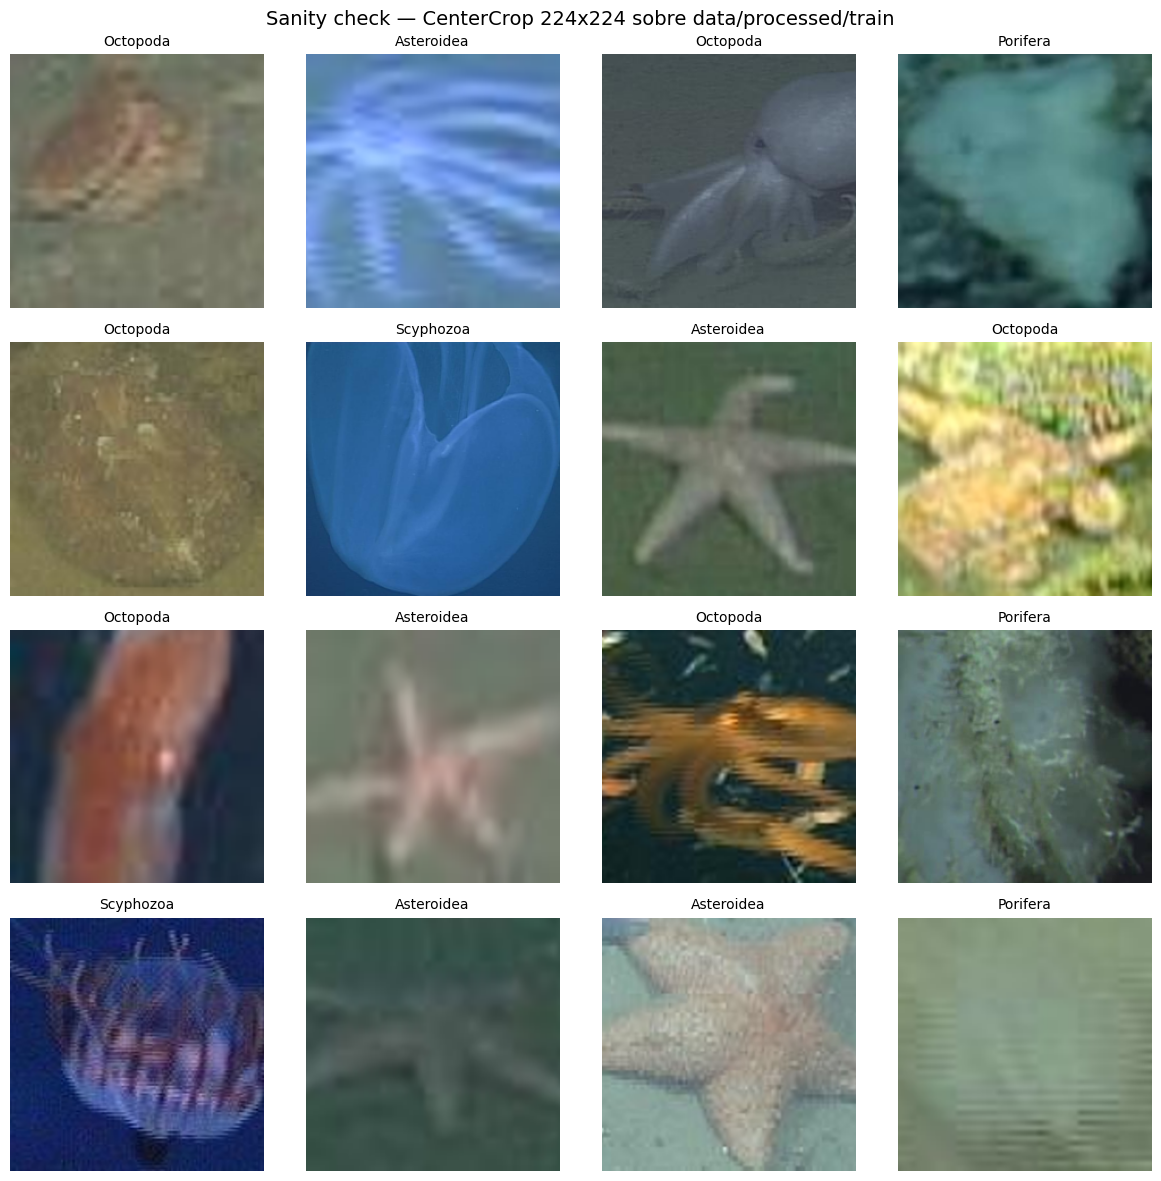

In [7]:
# === CELDA 7: Sanity Check Visual (¿qué verá la red neuronal?) ===
import os, glob, random
import matplotlib.pyplot as plt
from PIL import Image

TARGET = 224   # tamaño de entrada típico de una CNN preentrenada (ImageNet)

def center_crop_cuadrado(im, size=TARGET):
    """Simula el preprocesamiento estándar tipo ImageNet:
    escala el lado más corto a `size` y recorta el CUADRADO central.
    Sirve para auditar el riesgo del recorte cuadrado: en frames panorámicos
    (16:9 de ROV) se descartan los bordes laterales, donde la fauna podría estar."""
    im = im.convert("RGB")
    w, h = im.size
    escala = size / min(w, h)
    im = im.resize((round(w * escala), round(h * escala)))
    w, h = im.size
    izq, arr = (w - size) // 2, (h - size) // 2
    return im.crop((izq, arr, izq + size, arr + size))

# Reunir todas las imágenes de train con su etiqueta (la carpeta = la clase).
rutas = []
train_dir = os.path.join(DATA_PROCESSED, "train")
for clase in sorted(os.listdir(train_dir)):
    for r in glob.glob(os.path.join(train_dir, clase, "*.jpg")):
        rutas.append((r, clase))

muestra = random.sample(rutas, min(16, len(rutas)))

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (ruta, clase) in zip(axes.ravel(), muestra):
    ax.imshow(center_crop_cuadrado(Image.open(ruta)))
    ax.set_title(clase, fontsize=10)
    ax.axis("off")
for ax in axes.ravel()[len(muestra):]:   # apagar ejes sobrantes
    ax.axis("off")
plt.suptitle(f"Sanity check — CenterCrop {TARGET}x{TARGET} sobre data/processed/train", fontsize=14)
plt.tight_layout()
plt.show()


## Celda 8 — Datasets y DataLoaders (PyTorch)

In [8]:
# === CELDA 8: Datasets y DataLoaders (PyTorch) ===
import os
from collections import Counter
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from PIL import Image

# --- Hiperparámetros de datos ---
IMG_SIZE: int = 224
BATCH_SIZE: int = 32
MEAN = [0.485, 0.456, 0.406]   # media de ImageNet (obligatoria al usar pesos preentrenados)
STD  = [0.229, 0.224, 0.225]   # desvío de ImageNet


class Letterbox:
    """Transformación PIL -> PIL que lleva la imagen a `size` x `size` SIN deformar.

    Redimensiona conservando el aspect ratio (el lado MAYOR pasa a medir `size`) y
    rellena el sobrante con negro (padding). Resuelve el problema del CenterCrop,
    que recortaba la fauna pegada a los bordes: con Letterbox no se descarta NADA
    del frame y tampoco se estira la imagen (no distorsiona las proporciones del
    animal, algo crítico para que la CNN aprenda morfología real)."""

    def __init__(self, size: int = 224, fill: int = 0) -> None:
        self.size: int = size          # lado del cuadrado de salida
        self.fill: int = fill          # color del padding (0 = negro)

    def __call__(self, img: Image.Image) -> Image.Image:
        img = img.convert("RGB")
        w, h = img.size
        escala: float = self.size / max(w, h)                 # el lado mayor -> size
        nw, nh = max(1, round(w * escala)), max(1, round(h * escala))
        img = img.resize((nw, nh), Image.BILINEAR)
        lienzo = Image.new("RGB", (self.size, self.size), (self.fill,) * 3)
        lienzo.paste(img, ((self.size - nw) // 2, (self.size - nh) // 2))  # centrado
        return lienzo


# --- Pipelines de transformaciones ---
# TRAIN: Letterbox -> augmentation dinámica (geométrica + color) -> tensor -> Normalize.
# La augmentation es "online" (distinta en cada época): multiplica la variedad
# efectiva del dataset y frena el overfitting de las clases minoritarias, que el
# sampler va a mostrar muchas veces repetidas.
transform_train = transforms.Compose([
    Letterbox(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15, fill=0),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# VAL: evaluación determinista, SIN augmentation. Solo Letterbox + Normalize.
transform_val = transforms.Compose([
    Letterbox(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# --- Datasets desde data/processed/ (ImageFolder etiqueta según el nombre de carpeta) ---
train_dataset = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "train"), transform=transform_train)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "val"),   transform=transform_val)
class_names = train_dataset.classes
num_classes: int = len(class_names)      # = 4 para tu dataset (se calcula, no se hardcodea)
print("Clases:", class_names, "| num_classes:", num_classes)

# --- WeightedRandomSampler: combate el desbalance 10:1 sobre-muestreando minorías ---
# Peso de cada clase = 1/frecuencia  ->  peso de cada muestra = peso de su clase.
# Con replacement=True, en cada época el flujo queda balanceado: Octopoda (35) se
# muestrea tan seguido como Porifera (358), SIN descartar datos (a diferencia del
# undersampling). Es la forma recomendada de atacar el desbalance sin perder señal.
targets = train_dataset.targets
conteos = Counter(targets)
peso_clase = {c: 1.0 / n for c, n in conteos.items()}
pesos_muestra = [peso_clase[t] for t in targets]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(pesos_muestra),
    num_samples=len(pesos_muestra),   # una época ve tantas muestras como el train original
    replacement=True,                 # imprescindible para poder repetir minorías
)
print("Conteo train por clase:", {class_names[c]: n for c, n in sorted(conteos.items())})

# --- DataLoaders ---
# IMPORTANTE: con sampler NO se pasa shuffle=True (el sampler ya define el orden).
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Batches -> train: {len(train_loader)} | val: {len(val_loader)}")


Clases: ['Asteroidea', 'Octopoda', 'Porifera', 'Scyphozoa'] | num_classes: 4
Conteo train por clase: {'Asteroidea': 663, 'Octopoda': 635, 'Porifera': 608, 'Scyphozoa': 643}
Batches -> train: 80 | val: 21


## Celda 9 — Modelo EfficientNet-B0 (Transfer Learning)

In [9]:
# === CELDA 9: Modelo EfficientNet-B0 (Transfer Learning) ===
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Dispositivo: CUDA (GPU NVIDIA) > MPS (Apple Silicon) > CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Dispositivo:", device)

# Pesos preentrenados en ImageNet. Se usa la API moderna 'weights=' porque
# 'pretrained=True' está deprecado en torchvision reciente.
pesos = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=pesos)

# --- Transfer Learning: congelar el backbone, reentrenar solo el clasificador ---
# Con 543 imágenes y desbalance fuerte, reentrenar SOLO la cabeza:
#   (a) reduce drásticamente el costo de cómputo  -> UBICUIDAD (RA2),
#   (b) minimiza el overfitting (hay muy pocos datos para mover millones de pesos).
# Si querés embeddings adaptados al dominio marino para el detector de anomalías,
# poné FINE_TUNE_COMPLETO=True (y el LR baja solo a 1e-4 más abajo).
FINE_TUNE_COMPLETO: bool = False
if not FINE_TUNE_COMPLETO:
    for p in model.features.parameters():
        p.requires_grad = False

# Reemplazar la capa final (1280 -> num_classes), conservando el Dropout original.
in_features: int = model.classifier[1].in_features      # 1280 en B0
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

# Optimizador SOLO sobre parámetros entrenables. AdamW = Adam + weight decay
# desacoplado (regulariza mejor que Adam clásico).
params_entrenables = [p for p in model.parameters() if p.requires_grad]
LR: float = 1e-4 if FINE_TUNE_COMPLETO else 1e-3
optimizer = torch.optim.AdamW(params_entrenables, lr=LR, weight_decay=1e-4)

# CrossEntropyLoss SIN class weights: el desbalance ya lo maneja el
# WeightedRandomSampler. Sumarle pesos a la loss sería corregir DOS veces.
criterion = nn.CrossEntropyLoss()
print(f"Parámetros entrenables: {sum(p.numel() for p in params_entrenables):,}")


Dispositivo: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]


Parámetros entrenables: 5,124


## Celda 10 — Entrenamiento y Validación (cabeza)

In [10]:
# === CELDA 10: Entrenamiento y Validación ===
from sklearn.metrics import f1_score, accuracy_score
import json

EPOCAS: int = 18
MODELO_PATH = os.path.join(PROJECT_DIR, "best_model_fase2.pth")
HISTORIAL_FASE2_PATH = os.path.join(PROJECT_DIR, "historial_fase2.json")


def correr_epoca(loader, entrenar: bool):
    """Una pasada completa por `loader`.
    Si entrenar=True, hace backprop y actualiza pesos. Devuelve
    (loss_promedio, accuracy, f1_macro) acumulando todas las predicciones."""
    model.train() if entrenar else model.eval()
    perdida_total: float = 0.0
    y_true, y_pred = [], []
    with torch.set_grad_enabled(entrenar):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if entrenar:
                optimizer.zero_grad()
            salidas = model(imgs)
            perdida = criterion(salidas, labels)
            if entrenar:
                perdida.backward()
                optimizer.step()
            perdida_total += perdida.item() * imgs.size(0)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(salidas.argmax(1).cpu().tolist())
    n = max(1, len(y_true))
    loss = perdida_total / n
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return loss, acc, f1


# IDEMPOTENCIA: si ya existe el checkpoint Y el historial de una corrida anterior,
# los reusamos en vez de gastar GPU reentrenando -mismo principio que la Celda 3
# ("idempotencia robusta" en la descarga de FathomNet) y la Celda 28 (harness de
# Fase 4). Cambiá FORZAR_REENTRENAMIENTO = True si modificaste EPOCAS u otro
# hiperparámetro y de verdad querés repetir el entrenamiento.
FORZAR_REENTRENAMIENTO = False

if not FORZAR_REENTRENAMIENTO and os.path.exists(MODELO_PATH) and os.path.exists(HISTORIAL_FASE2_PATH):
    model.load_state_dict(torch.load(MODELO_PATH, map_location=device))
    model = model.to(device)
    with open(HISTORIAL_FASE2_PATH) as f:
        guardado = json.load(f)
    hist = guardado["hist"]
    mejor_f1 = guardado["mejor_f1"]
    print(f"Ya entrenado en una corrida anterior -> reusando checkpoint e historial "
          f"(mejor F1 val = {mejor_f1:.3f}). 0 minutos de GPU gastados.")
else:
    hist = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1"]}
    mejor_f1: float = -1.0

    for ep in range(1, EPOCAS + 1):
        tl, ta, tf = correr_epoca(train_loader, entrenar=True)
        vl, va, vf = correr_epoca(val_loader,   entrenar=False)
        for k, v in zip(["train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1"],
                        [tl, vl, ta, va, tf, vf]):
            hist[k].append(v)
        print(f"Época {ep:02d}/{EPOCAS} | "
              f"train: loss {tl:.3f} acc {ta:.3f} f1 {tf:.3f} | "
              f"val: loss {vl:.3f} acc {va:.3f} f1 {vf:.3f}")

        # Se guarda el mejor modelo por F1 MACRO de validación, NO por accuracy:
        # con desbalance, accuracy premia predecir siempre la clase mayoritaria
        # (Porifera); el F1 macro promedia el desempeño por clase y castiga ignorar
        # a Octopoda/Scyphozoa.
        if vf > mejor_f1:
            mejor_f1 = vf
            torch.save(model.state_dict(), MODELO_PATH)
            print(f"   * nuevo mejor F1 val = {vf:.3f} -> guardado en {MODELO_PATH}")

    print(f"\nEntrenamiento terminado. Mejor F1 macro (val): {mejor_f1:.3f}")

    # Guardar el historial junto al checkpoint -es lo que permite saltar el
    # reentrenamiento la próxima vez que se corra esta celda.
    with open(HISTORIAL_FASE2_PATH, "w") as f:
        json.dump({"hist": hist, "mejor_f1": mejor_f1}, f)

Ya entrenado en una corrida anterior -> reusando checkpoint e historial (mejor F1 val = 0.879). 0 minutos de GPU gastados.


## Celda 11 — Visualización de Resultados (Fase 2)

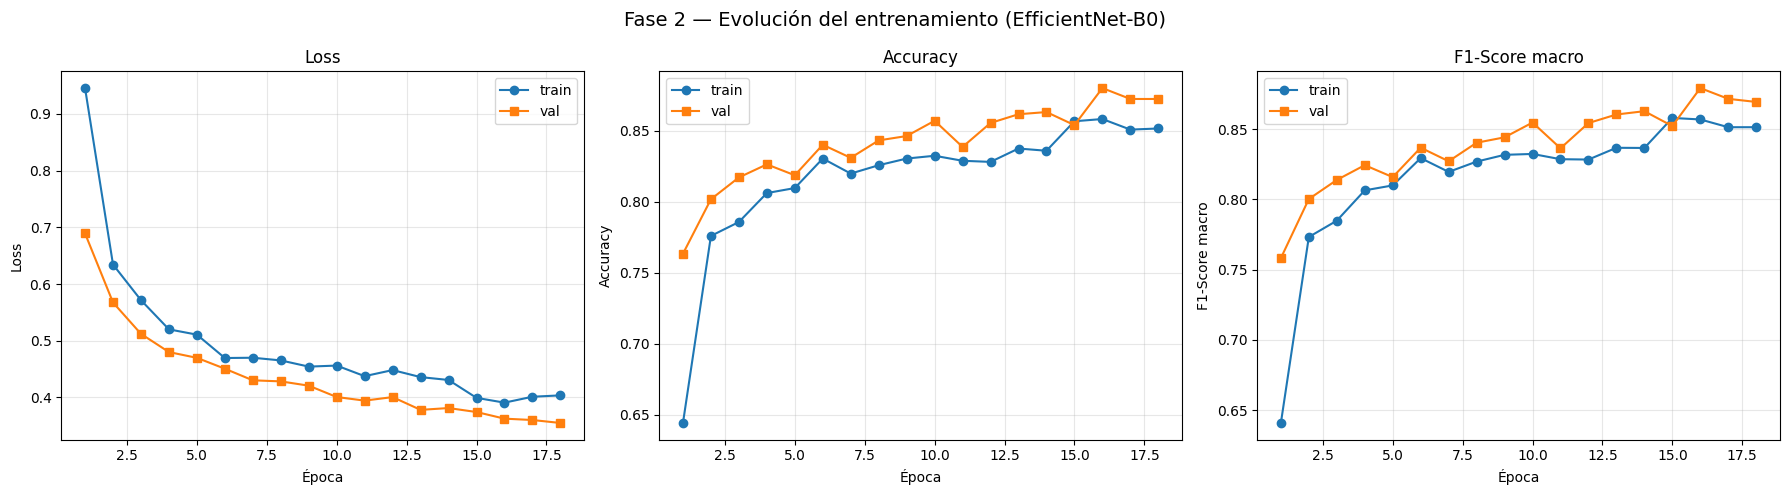

In [11]:
# === CELDA 11: Visualización de Resultados ===
import matplotlib.pyplot as plt

epocas = range(1, len(hist["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (clave, titulo) in zip(axes, [("loss", "Loss"), ("acc", "Accuracy"), ("f1", "F1-Score macro")]):
    ax.plot(epocas, hist[f"train_{clave}"], "o-", label="train")
    ax.plot(epocas, hist[f"val_{clave}"],   "s-", label="val")
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.set_ylabel(titulo)
    ax.grid(alpha=0.3)
    ax.legend()
plt.suptitle("Fase 2 — Evolución del entrenamiento (EfficientNet-B0)", fontsize=14)
plt.tight_layout()
plt.show()


## Celda 12 — Fine-Tuning Completo del Backbone (Fase 2.5)

Ya fine-tuneado en una corrida anterior -> reusando checkpoint e historial (F1 base 0.879 -> mejor F1 0.939). 0 minutos de GPU gastados.


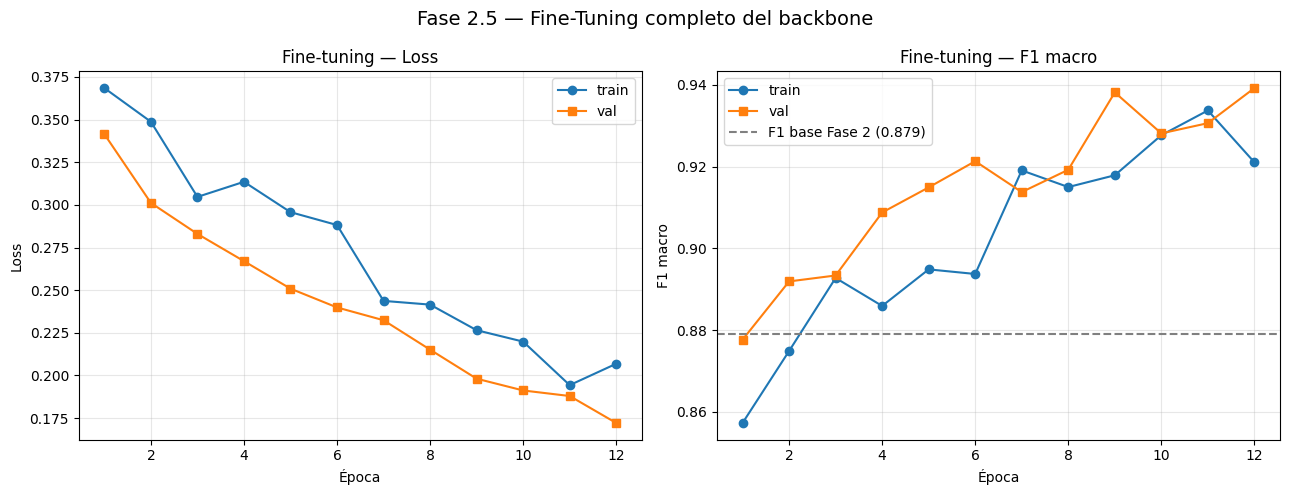

In [12]:
# === CELDA 12: Fine-Tuning Completo del Backbone (Fase 2.5) ===
import matplotlib.pyplot as plt
import json

MODELO_FT_PATH = os.path.join(PROJECT_DIR, "best_model_finetuned.pth")
HISTORIAL_FASE25_PATH = os.path.join(PROJECT_DIR, "historial_fase2_5.json")
EPOCAS_FT: int = 12      # ciclo corto: el backbone ya viene preentrenado + ajustado
PACIENCIA: int = 4       # early stopping: épocas seguidas sin mejorar antes de cortar

# IDEMPOTENCIA: si ya existe el checkpoint fine-tuneado Y su historial de una
# corrida anterior, los reusamos -mismo principio que la Celda 10 y la Celda 28.
# Cambiá FORZAR_REENTRENAMIENTO = True para repetir el fine-tuning de verdad.
FORZAR_REENTRENAMIENTO = False

if not FORZAR_REENTRENAMIENTO and os.path.exists(MODELO_FT_PATH) and os.path.exists(HISTORIAL_FASE25_PATH):
    model.load_state_dict(torch.load(MODELO_FT_PATH, map_location=device))
    model = model.to(device)
    with open(HISTORIAL_FASE25_PATH) as f:
        guardado = json.load(f)
    hist_ft = guardado["hist_ft"]
    f1_base = guardado["f1_base"]
    mejor_f1_ft = guardado["mejor_f1_ft"]
    print(f"Ya fine-tuneado en una corrida anterior -> reusando checkpoint e historial "
          f"(F1 base {f1_base:.3f} -> mejor F1 {mejor_f1_ft:.3f}). 0 minutos de GPU gastados.")
else:
    # 1) CARGA: traer los pesos de la Fase 2. Importante: el 'model' en memoria tras
    #    la Celda 10 es el de la ÚLTIMA época, no el mejor. Recargar el checkpoint
    #    garantiza que partimos del mejor estado, no de uno cualquiera.
    model.load_state_dict(torch.load(MODELO_PATH, map_location=device))
    model = model.to(device)

    # 2) DESCONGELAR TODO: ahora el backbone también recibe gradiente y aprende.
    for p in model.parameters():
        p.requires_grad = True

    # 3) DIFFERENTIAL LEARNING RATES (mitiga el Catastrophic Forgetting mejor que un
    #    LR único). Las capas tempranas codifican rasgos universales (bordes, texturas)
    #    que ya son buenos -> se mueven con un LR ínfimo. Las capas tardías y la cabeza,
    #    más específicas, se adaptan algo más al dominio oceánico profundo.
    bloques = list(model.features.children())                              # 9 bloques en B0
    params_tempranos = [p for b in bloques[:5] for p in b.parameters()]    # genéricos  -> LR ínfimo
    params_tardios   = [p for b in bloques[5:] for p in b.parameters()]    # específicos -> LR micro
    params_cabeza    = list(model.classifier.parameters())                 # clasificador

    optimizer = torch.optim.AdamW([
        {"params": params_tempranos, "lr": 1e-6},
        {"params": params_tardios,   "lr": 1e-5},
        {"params": params_cabeza,    "lr": 5e-5},
    ], weight_decay=1e-4)
    # (Alternativa más conservadora: un único lr=1e-5 para todos los parámetros.)
    print(f"Fine-tuning de {sum(p.numel() for p in model.parameters()):,} parámetros (todos entrenables)")

    # 4) BASELINE: evaluamos el modelo cargado ANTES de tocar nada. Así sabemos si el
    #    fine-tuning realmente raspa puntos sobre 0.727 o solo estabiliza la red.
    _, _, f1_base = correr_epoca(val_loader, entrenar=False)
    print(f"F1 macro val de partida (Fase 2): {f1_base:.3f}")
    torch.save(model.state_dict(), MODELO_FT_PATH)   # el 'mejor' arranca siendo el baseline

    # 5) CICLO con EARLY STOPPING por F1 macro de validación.
    hist_ft = {k: [] for k in ["train_loss", "val_loss", "train_f1", "val_f1"]}
    mejor_f1_ft = f1_base
    sin_mejora = 0

    for ep in range(1, EPOCAS_FT + 1):
        tl, ta, tf = correr_epoca(train_loader, entrenar=True)
        vl, va, vf = correr_epoca(val_loader,   entrenar=False)
        for k, v in zip(["train_loss", "val_loss", "train_f1", "val_f1"], [tl, vl, tf, vf]):
            hist_ft[k].append(v)
        print(f"FT época {ep:02d}/{EPOCAS_FT} | train loss {tl:.3f} f1 {tf:.3f} | "
              f"val loss {vl:.3f} f1 {vf:.3f}")

        if vf > mejor_f1_ft:
            mejor_f1_ft = vf
            sin_mejora = 0
            torch.save(model.state_dict(), MODELO_FT_PATH)
            print(f"   * mejora: F1 val {vf:.3f} -> guardado en {MODELO_FT_PATH}")
        else:
            sin_mejora += 1
            if sin_mejora >= PACIENCIA:
                print(f"   Early stopping: {PACIENCIA} épocas sin mejorar.")
                break

    print(f"\nFine-tuning terminado. F1 base {f1_base:.3f} -> mejor F1 {mejor_f1_ft:.3f} "
          f"(delta {mejor_f1_ft - f1_base:+.3f})")

    # Guardar el historial junto al checkpoint -es lo que permite saltar el
    # reentrenamiento la próxima vez que se corra esta celda.
    with open(HISTORIAL_FASE25_PATH, "w") as f:
        json.dump({"hist_ft": hist_ft, "f1_base": f1_base, "mejor_f1_ft": mejor_f1_ft}, f)

# 6) GRÁFICOS específicos de esta sub-fase (siempre corre, haya entrenado o no).
ep_range = range(1, len(hist_ft["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(ep_range, hist_ft["train_loss"], "o-", label="train")
ax1.plot(ep_range, hist_ft["val_loss"],   "s-", label="val")
ax1.set_title("Fine-tuning — Loss"); ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
ax1.grid(alpha=0.3); ax1.legend()
ax2.plot(ep_range, hist_ft["train_f1"], "o-", label="train")
ax2.plot(ep_range, hist_ft["val_f1"],   "s-", label="val")
ax2.axhline(f1_base, ls="--", color="gray", label=f"F1 base Fase 2 ({f1_base:.3f})")
ax2.set_title("Fine-tuning — F1 macro"); ax2.set_xlabel("Época"); ax2.set_ylabel("F1 macro")
ax2.grid(alpha=0.3); ax2.legend()
plt.suptitle("Fase 2.5 — Fine-Tuning completo del backbone", fontsize=14)
plt.tight_layout(); plt.show()

## Celda 13 — Diagnóstico — Matriz de Confusión + F1 por Clase

Diagnóstico sobre: best_model_finetuned.pth 

              precision    recall  f1-score   support

  Asteroidea      0.940     0.912     0.926       137
    Octopoda      0.967     0.885     0.924       165
    Porifera      0.913     0.979     0.945       192
   Scyphozoa      0.950     0.975     0.962       157

    accuracy                          0.940       651
   macro avg      0.942     0.938     0.939       651
weighted avg      0.941     0.940     0.940       651

Clase más débil: Octopoda  (F1 = 0.924)


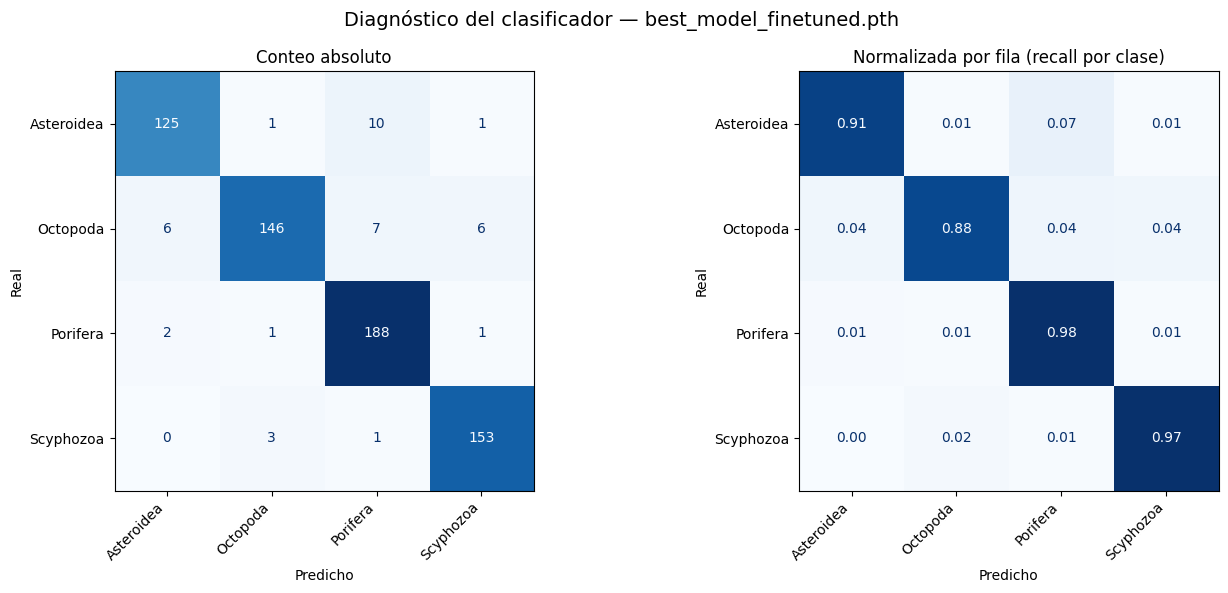

In [13]:
# === CELDA 13: Diagnóstico — Matriz de Confusión + F1 por Clase ===
# No entrena: solo INSTRUMENTA. Carga el mejor modelo y disecciona su desempeño
# clase por clase sobre validación, para ver dónde está realmente el problema
# (en vez de mirar un único F1 macro que promedia todo y esconde el detalle).
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

# Modelo a diagnosticar. Por defecto el mejor (fine-tuned). Cambiá a MODELO_PATH
# para diagnosticar el de solo-cabeza (Fase 2) y comparar.
CHECKPOINT = MODELO_FT_PATH
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model = model.to(device)
model.eval()

# Inferencia determinista sobre validación (val_loader ya va SIN augmentation).
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        y_true.extend(labels.tolist())
        y_pred.extend(preds.tolist())

labels_idx = list(range(len(class_names)))

# --- Reporte por clase: precision, recall, F1 y SUPPORT (nº de imágenes en val) ---
# 'support' es clave acá: te recuerda con cuántas imágenes se midió cada F1.
print("Diagnóstico sobre:", os.path.basename(CHECKPOINT), "\n")
print(classification_report(y_true, y_pred, labels=labels_idx,
                            target_names=class_names, zero_division=0, digits=3))

# Clase más débil -> dónde conviene invertir (más datos, etc.).
f1_por_clase = f1_score(y_true, y_pred, average=None, labels=labels_idx, zero_division=0)
peor = class_names[int(np.argmin(f1_por_clase))]
print(f"Clase más débil: {peor}  (F1 = {f1_por_clase.min():.3f})")

# --- Matrices de confusión: cruda + normalizada por fila ---
# La normalizada por fila = RECALL por clase: de todas las imágenes que ERAN de
# la clase X, qué fracción se predijo bien (diagonal) y a dónde se fugaron las
# confusiones (fuera de la diagonal). Imprescindible con clases desbalanceadas,
# porque la matriz cruda está dominada visualmente por Porifera.
cm      = confusion_matrix(y_true, y_pred, labels=labels_idx)
cm_norm = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="true")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title("Conteo absoluto")
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    ax=ax2, cmap="Blues", colorbar=False, values_format=".2f")
ax2.set_title("Normalizada por fila (recall por clase)")
for ax in (ax1, ax2):
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_xticklabels(class_names, rotation=45, ha="right")
plt.suptitle(f"Diagnóstico del clasificador — {os.path.basename(CHECKPOINT)}", fontsize=14)
plt.tight_layout()
plt.show()


## Celda 14 — Extracción de Embeddings (Fase 3, paso 1/4)

Pegar al final del notebook. Reutiliza `transform_val`, `class_names` (Celda 8), `device` (Celda 9), `DATA_PROCESSED` y `PROJECT_DIR` (Celda 1), y el archivo `best_model_finetuned.pth`.

In [14]:
# === CELDA 14: Extracción de Embeddings (Fase 3) ===
# Convierte cada imagen en su "huella visual": el vector de 1280 dimensiones que
# la red aprendió, ANTES del clasificador. Sobre estos vectores vamos a montar el
# detector de anomalías. Se guardan en Drive para no recalcularlos cada vez.
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.models import efficientnet_b0
from torch.utils.data import DataLoader

MODELO_FT_PATH = os.path.join(PROJECT_DIR, "best_model_finetuned.pth")

# 1) Reconstruir la arquitectura y cargar NUESTROS pesos fine-tuneados.
#    weights=None: no bajamos los de ImageNet, cargamos los del .pth.
extractor = efficientnet_b0(weights=None)
extractor.classifier[1] = nn.Linear(extractor.classifier[1].in_features, len(class_names))
extractor.load_state_dict(torch.load(MODELO_FT_PATH, map_location=device))

# 2) "Decapitar" la red: reemplazar el clasificador por Identity. Ahora el modelo
#    devuelve el embedding de 1280-D (la capa de pooling), no las 4 probabilidades.
extractor.classifier = nn.Identity()
extractor = extractor.to(device).eval()

# 3) Datasets DETERMINISTAS: mismo transform que validación (Letterbox + Normalize,
#    SIN augmentation). Para los embeddings queremos la representación estable de
#    cada imagen, no una versión rotada/jiteada al azar.
ds_train = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "train"), transform=transform_val)
ds_val   = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "val"),   transform=transform_val)


def extraer_embeddings(dataset, etiqueta):
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    embs, labels = [], []
    with torch.no_grad():
        for imgs, y in loader:
            z = extractor(imgs.to(device))      # (B, 1280)
            embs.append(z.cpu().numpy())
            labels.append(y.numpy())
    embs = np.concatenate(embs)
    labels = np.concatenate(labels)
    print(f"   {etiqueta:5s}: embeddings {embs.shape} | etiquetas {labels.shape}")
    return embs, labels


print("Extrayendo embeddings de 1280-D...")
X_train, y_train = extraer_embeddings(ds_train, "train")
X_val,   y_val   = extraer_embeddings(ds_val,   "val")

# 4) Guardar en Drive (con rutas y nombres de clase, para poder rastrear después
#    QUÉ imagen marca el detector como anomalía).
rutas_train = [p for p, _ in ds_train.samples]
rutas_val   = [p for p, _ in ds_val.samples]
np.savez(os.path.join(PROJECT_DIR, "embeddings_train.npz"),
         X=X_train, y=y_train, rutas=rutas_train, clases=class_names)
np.savez(os.path.join(PROJECT_DIR, "embeddings_val.npz"),
         X=X_val, y=y_val, rutas=rutas_val, clases=class_names)
print(f"\nGuardados: embeddings_train.npz ({X_train.shape}) y embeddings_val.npz ({X_val.shape})")
print("class_names:", class_names)


Extrayendo embeddings de 1280-D...
   train: embeddings (2549, 1280) | etiquetas (2549,)
   val  : embeddings (651, 1280) | etiquetas (651,)

Guardados: embeddings_train.npz ((2549, 1280)) y embeddings_val.npz ((651, 1280))
class_names: ['Asteroidea', 'Octopoda', 'Porifera', 'Scyphozoa']


## Celda 15 — Visualización del Espacio Latente con UMAP (Fase 3, paso 2/4)

Pegar al final del notebook. Reutiliza `PROJECT_DIR` (Celda 1) y los archivos `embeddings_train.npz` / `embeddings_val.npz` (Celda 14). Esta celda es puramente diagnóstica: no se usa para entrenar ningún modelo posterior.

Embeddings de validación cargados: (651, 1280)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


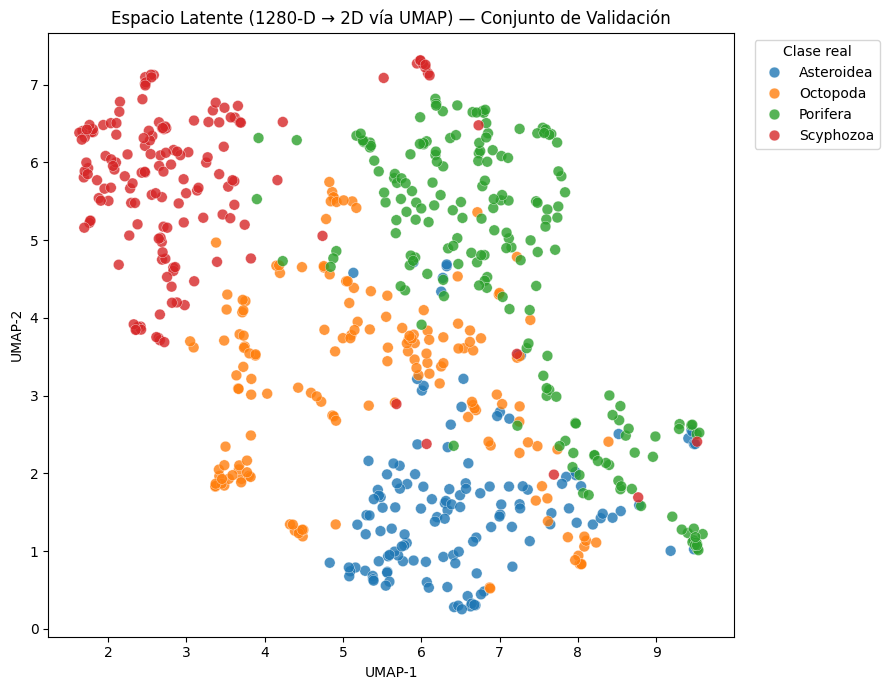

In [15]:
# === CELDA 15: Visualización del Espacio Latente con UMAP (Fase 3, paso 2/4) ===
#
# ¿Por qué UMAP y no t-SNE?
#   - t-SNE solo preserva vecindarios LOCALES: la distancia entre dos clusters lejanos
#     en el gráfico NO es interpretable. Además es no-determinista entre corridas y no
#     tiene un método .transform() real para proyectar puntos nuevos.
#   - UMAP preserva estructura LOCAL y GLOBAL (la separación relativa entre clusters sí
#     dice algo), es determinista fijando random_state, y escala mejor. Esto importa
#     porque más adelante, si querés ubicar una muestra real "Desconocida" en este mismo
#     mapa, UMAP te lo permite sin recalcular todo de cero.
#
# ALERTA (para que no te la marque la cátedra): esta proyección 2D es PURAMENTE
# DIAGNÓSTICA. NUNCA hay que entrenar el detector de anomalías sobre estas 2 dimensiones
# -- UMAP descarta información a propósito para poder graficar, y la señal de "esto es
# raro" en un embedding de 1280-D suele vivir justo en las dimensiones que UMAP comprime.
# El IsolationForest de la Celda 16 trabaja sobre los 1280-D crudos.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import umap
except ImportError:
    %pip install -q umap-learn
    import umap

# 1) Cargar embeddings de validación desde Drive (independiente del estado del kernel:
#    si la sesión se reinició, esta celda corre sola sin necesidad de re-ejecutar todo).
data_val   = np.load(os.path.join(PROJECT_DIR, "embeddings_val.npz"), allow_pickle=True)
X_val_viz  = data_val["X"]
y_val_viz  = data_val["y"]
clases_viz = list(data_val["clases"])

print(f"Embeddings de validación cargados: {X_val_viz.shape}")

# 2) Ajustamos UMAP SOLO sobre validación: es el único conjunto que el modelo nunca vio
#    durante entrenamiento, así que es el más honesto para auditar si el espacio latente
#    generaliza (y no un artefacto de memorización sobre train).
reducer = umap.UMAP(
    n_neighbors=15,    # vecindario amplio -> prioriza estructura GLOBAL de clusters
    min_dist=0.1,      # cuánto se compactan los puntos dentro de un mismo cluster
    n_components=2,
    metric="cosine",   # los embeddings post-pooling de EfficientNet son direccionales;
                       # coseno suele separar clases mejor que distancia euclídea acá
    random_state=42,   # UMAP es estocástico internamente -> fijamos semilla
)
emb_2d = reducer.fit_transform(X_val_viz)

# 3) Graficar coloreando por clase real
df_plot = pd.DataFrame({
    "UMAP-1": emb_2d[:, 0],
    "UMAP-2": emb_2d[:, 1],
    "Clase real": [clases_viz[i] for i in y_val_viz],
})

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_plot, x="UMAP-1", y="UMAP-2", hue="Clase real",
    palette="tab10", s=60, alpha=0.8, edgecolor="white", linewidth=0.3,
)
plt.title("Espacio Latente (1280-D → 2D vía UMAP) — Conjunto de Validación")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.legend(title="Clase real", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 4) Lectura crítica: si una clase aparece partida en sub-clusters, puede ser
#    variabilidad real (poses/profundidades distintas) o una señal de subgrupos
#    heterogéneos dentro de esa clase -> vale la pena mencionarlo en el informe.

## Celda 16 — Detección de Anomalías con Isolation Forest (Fase 3, paso 3/4)

Pegar al final del notebook. Reutiliza `PROJECT_DIR` (Celda 1) y los archivos `embeddings_train.npz` / `embeddings_val.npz` (Celda 14).

> **Nota:** este fue el **primer** detector evaluado. La validación contra una especie real nunca vista (Celdas 19-21) mostró que no generaliza a OOD genuino. El método de detección (Mahalanobis) que se valida en esta fase se reutiliza luego sobre la arquitectura final del proyecto (Fase 7) — esta celda se conserva como el punto donde se desarrolló y validó la metodología, no como el sistema final de producción.

In [16]:
# === CELDA 16: Detección de Anomalías con Isolation Forest (Fase 3, paso 3/4) ===
#
# ¿Por qué Isolation Forest?
#   - No asume ninguna forma geométrica para la "normalidad" (a diferencia de, por
#     ejemplo, un umbral de distancia a centroides, que asume clusters esféricos).
#     Aísla puntos por particiones aleatorias recursivas: una anomalía requiere MENOS
#     particiones para quedar aislada que un punto típico.
#   - Es no-paramétrico y eficiente en alta dimensión (1280-D) sin necesitar calcular
#     todas las distancias par-a-par, que sí necesitaría algo como Local Outlier Factor.
#
# ALERTA DE DATA LEAKAGE (crítica en Open-Set Recognition):
#   El modelo se entrena EXCLUSIVAMENTE con X_train. Si se filtrara X_val -o peor, una
#   muestra realmente anómala- en el fit, el detector "vería" antes de tiempo lo que
#   después le pedimos detectar como desconocido, y cualquier métrica de falsa alarma
#   que calculemos quedaría invalidada.
#
# ALERTA METODOLÓGICA (qué SÍ y qué NO mide esta celda):
#   Tu set de validación tiene ÚNICAMENTE las 4 clases conocidas. Por lo tanto, esta
#   celda NO puede medir la sensibilidad real del detector (qué % de un objeto
#   verdaderamente nuevo sería marcado "Desconocido"), porque en val no hay ningún
#   ejemplo verdaderamente Out-of-Distribution. Lo que SÍ medimos es la TASA DE FALSA
#   ALARMA: de imágenes que sabemos son de una especie conocida, ¿qué % el modelo
#   etiqueta erróneamente como "Desconocido"? Para completar la evaluación de OSR en
#   el informe final, conviene sumar un 5to conjunto con una clase de FathomNet NO usada
#   en entrenamiento, y ahí sí reportar la tasa de detección real.
#
# CALIBRACIÓN DE contamination (actualizado tras el diagnóstico de la Celda 17):
#   Con contamination="auto", scikit-learn fija el umbral de decisión en offset_=-0.5,
#   un valor heredado del paper original que NO se calibra contra la escala real de
#   nuestros datos. La Celda 17 mostró que decision_function() en este embedding vive
#   en el rango [~0.01, ~0.14] -muy lejos de -0.5- así que con "auto" el detector NUNCA
#   marcaba nada como "Desconocido" (0.00% de falsa alarma, pero por la razón
#   equivocada: un umbral roto, no un modelo preciso).
#   Elegimos contamination=0.02 (percentil 2% de los scores de TRAIN) porque: (a) sin
#   ejemplos reales Out-of-Distribution no hay forma de optimizar este valor contra una
#   métrica de detección real, queda como hiperparámetro de sensibilidad calibrado por
#   criterio; (b) en la simulación de la Celda 17, este percentil da una falsa alarma
#   baja y reportable (~2% en train, ~1.2% en val) sin volver a caer en el extremo de
#   "nunca dispara".

import os
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# 1) Cargar embeddings
data_train = np.load(os.path.join(PROJECT_DIR, "embeddings_train.npz"), allow_pickle=True)
data_val   = np.load(os.path.join(PROJECT_DIR, "embeddings_val.npz"),   allow_pickle=True)

X_train_if = data_train["X"]
X_val_if   = data_val["X"]
y_val_if   = data_val["y"]
clases_if  = list(data_val["clases"])
rutas_val_if = data_val["rutas"]

# 2) Entrenar SOLO con embeddings de entrenamiento.
#    contamination=0.02: ver justificación arriba (calibrado con la Celda 17, NO "auto").
iso_forest = IsolationForest(
    n_estimators=200,     # más árboles -> score de anomalía más estable, menos varianza
    max_samples="auto",   # min(256, n_samples) por árbol -> decorrelaciona los árboles
    contamination=0.02,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_if)

# 3) Inferencia sobre validación + mapeo al vocabulario del dominio
pred_raw = iso_forest.predict(X_val_if)            # 1 = inlier, -1 = outlier
mapa_estado = {1: "Especie Conocida", -1: "Desconocido"}
pred_estado = np.array([mapa_estado[p] for p in pred_raw])

anomaly_score = iso_forest.decision_function(X_val_if)

df_reporte = pd.DataFrame({
    "clase_real":     [clases_if[i] for i in y_val_if],
    "prediccion_OSR": pred_estado,
    "anomaly_score":  anomaly_score,
    "ruta":           rutas_val_if,
})

# 4) Reporte de FALSAS ALARMAS
total_val        = len(df_reporte)
n_falsas_alarmas = (df_reporte["prediccion_OSR"] == "Desconocido").sum()
tasa_falsa_alarma = n_falsas_alarmas / total_val

print(f"contamination usado            : 0.02 (calibrado en Celda 17, no 'auto')")
print(f"Total muestras de validación   : {total_val}")
print(f"Falsas alarmas ('Desconocido' siendo en realidad conocida): {n_falsas_alarmas}")
print(f"Tasa de falsa alarma global    : {tasa_falsa_alarma:.2%}\n")

print("Tasa de falsa alarma desagregada por clase real:")
resumen_por_clase = (
    df_reporte
    .groupby("clase_real")["prediccion_OSR"]
    .apply(lambda s: (s == "Desconocido").mean())
    .rename("tasa_falsa_alarma")
    .sort_values(ascending=False)
)
print(resumen_por_clase.round(4))

print("\nTop-5 muestras más anómalas (menor anomaly_score) — revisar manualmente:")
print(df_reporte.sort_values("anomaly_score").head(5)[["clase_real", "anomaly_score", "ruta"]]
      .to_string(index=False))

contamination usado            : 0.02 (calibrado en Celda 17, no 'auto')
Total muestras de validación   : 651
Falsas alarmas ('Desconocido' siendo en realidad conocida): 15
Tasa de falsa alarma global    : 2.30%

Tasa de falsa alarma desagregada por clase real:
clase_real
Octopoda      0.0545
Porifera      0.0156
Scyphozoa     0.0127
Asteroidea    0.0073
Name: tasa_falsa_alarma, dtype: float64

Top-5 muestras más anómalas (menor anomaly_score) — revisar manualmente:
clase_real  anomaly_score                                                                                                 ruta
  Porifera      -0.023920  /content/drive/MyDrive/IC415/data/processed/val/Porifera/88a8a4ef-c660-4d69-afca-954769e91ebc_0.jpg
  Octopoda      -0.022769  /content/drive/MyDrive/IC415/data/processed/val/Octopoda/ee7fca6d-f8e8-4dbe-813e-464ff6c3b050_0.jpg
  Octopoda      -0.022769    /content/drive/MyDrive/IC415/data/processed/val/Octopoda/b435a38a-e859-4f1a-bc8d-a0fc718b2fd1.jpg
 Scyphozoa      -0.01

## Celda 17 — Diagnóstico de Calibración del Umbral de Anomalía (Fase 3, paso 4/4)

Pegar al final del notebook, después de la Celda 16. Esta celda **no modifica** el `IsolationForest` de la Celda 16 — es puramente diagnóstica, para decidir con evidencia (y no a ojo) si hay que recalibrar `contamination` antes de cerrar la Fase 3.

offset_ (umbral fijo con contamination='auto'): -0.5000

Estadísticos de decision_function:
           train       val
count  2549.0000  651.0000
mean      0.0965    0.0963
std       0.0187    0.0186
min       0.0156    0.0303
25%       0.0849    0.0837
50%       0.0980    0.0974
75%       0.1103    0.1101
max       0.1390    0.1380


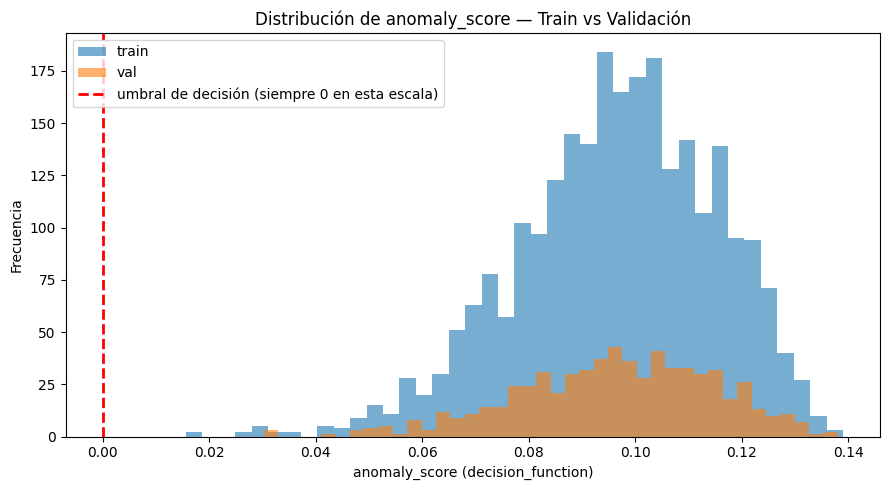


Simulación de tasas de alarma con distintos umbrales (percentiles de TRAIN):
  percentil  1% de train (umbral=0.0469) -> alarma en train: 0.98% | alarma en val: 0.77%
  percentil  2% de train (umbral=0.0542) -> alarma en train: 2.00% | alarma en val: 2.30%
  percentil  5% de train (umbral=0.0633) -> alarma en train: 5.02% | alarma en val: 4.61%
  percentil 10% de train (umbral=0.0715) -> alarma en train: 10.00% | alarma en val: 9.83%


In [17]:
# === CELDA 17: Diagnóstico de Calibración del Umbral de Anomalía (Fase 3, paso 4/4) ===
#
# Esta celda ya cumplió su propósito (fue la que usamos para elegir contamination=0.02
# en la Celda 16). La dejamos en el notebook porque documenta CÓMO se llegó a ese
# número -evidencia para el informe-, no porque haga falta volver a correrla.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

data_train = np.load(os.path.join(PROJECT_DIR, "embeddings_train.npz"), allow_pickle=True)
data_val   = np.load(os.path.join(PROJECT_DIR, "embeddings_val.npz"),   allow_pickle=True)
X_train_diag = data_train["X"]
X_val_diag   = data_val["X"]

iso_diag = IsolationForest(
    n_estimators=200, max_samples="auto", contamination="auto",
    random_state=42, n_jobs=-1,
)
iso_diag.fit(X_train_diag)

# Sufijo _diag para no colisionar con scores_train/scores_val de la Celda 21
# (mismo nombre, modelo distinto -> evita pisar variables si se corre fuera de orden).
scores_train_diag = iso_diag.decision_function(X_train_diag)
scores_val_diag   = iso_diag.decision_function(X_val_diag)

print(f"offset_ (umbral fijo con contamination='auto'): {iso_diag.offset_:.4f}")
print()
print("Estadísticos de decision_function:")
print(pd.DataFrame({
    "train": pd.Series(scores_train_diag).describe(),
    "val":   pd.Series(scores_val_diag).describe(),
}).round(4))

# decision_function() = score_samples() - offset_, así que el umbral de decisión en
# ESTA escala es SIEMPRE 0, sin importar cuánto valga offset_. Graficamos un único
# umbral, correctamente ubicado.
plt.figure(figsize=(9, 5))
plt.hist(scores_train_diag, bins=40, alpha=0.6, label="train", color="#1f77b4")
plt.hist(scores_val_diag, bins=40, alpha=0.6, label="val", color="#ff7f0e")
plt.axvline(0, color="red", linestyle="--", linewidth=2,
            label="umbral de decisión (siempre 0 en esta escala)")
plt.xlabel("anomaly_score (decision_function)")
plt.ylabel("Frecuencia")
plt.title("Distribución de anomaly_score — Train vs Validación")
plt.legend()
plt.tight_layout()
plt.show()

print("\nSimulación de tasas de alarma con distintos umbrales (percentiles de TRAIN):")
for pct in [1, 2, 5, 10]:
    umbral_pct = np.percentile(scores_train_diag, pct)
    alarma_train = (scores_train_diag < umbral_pct).mean()
    alarma_val   = (scores_val_diag < umbral_pct).mean()
    print(f"  percentil {pct:>2}% de train (umbral={umbral_pct:.4f}) -> "
          f"alarma en train: {alarma_train:.2%} | alarma en val: {alarma_val:.2%}")

## Celda 18 — Figura de Cierre del Primer Detector (Isolation Forest): Top-6 Muestras Más Anómalas

> Esta es la figura de cierre del **primer** detector (Isolation Forest). La figura del sistema de detección FINAL de producción está en el cierre de la Fase 7.

Figura guardada en: /content/drive/MyDrive/IC415/fig_top_anomalas_val.png


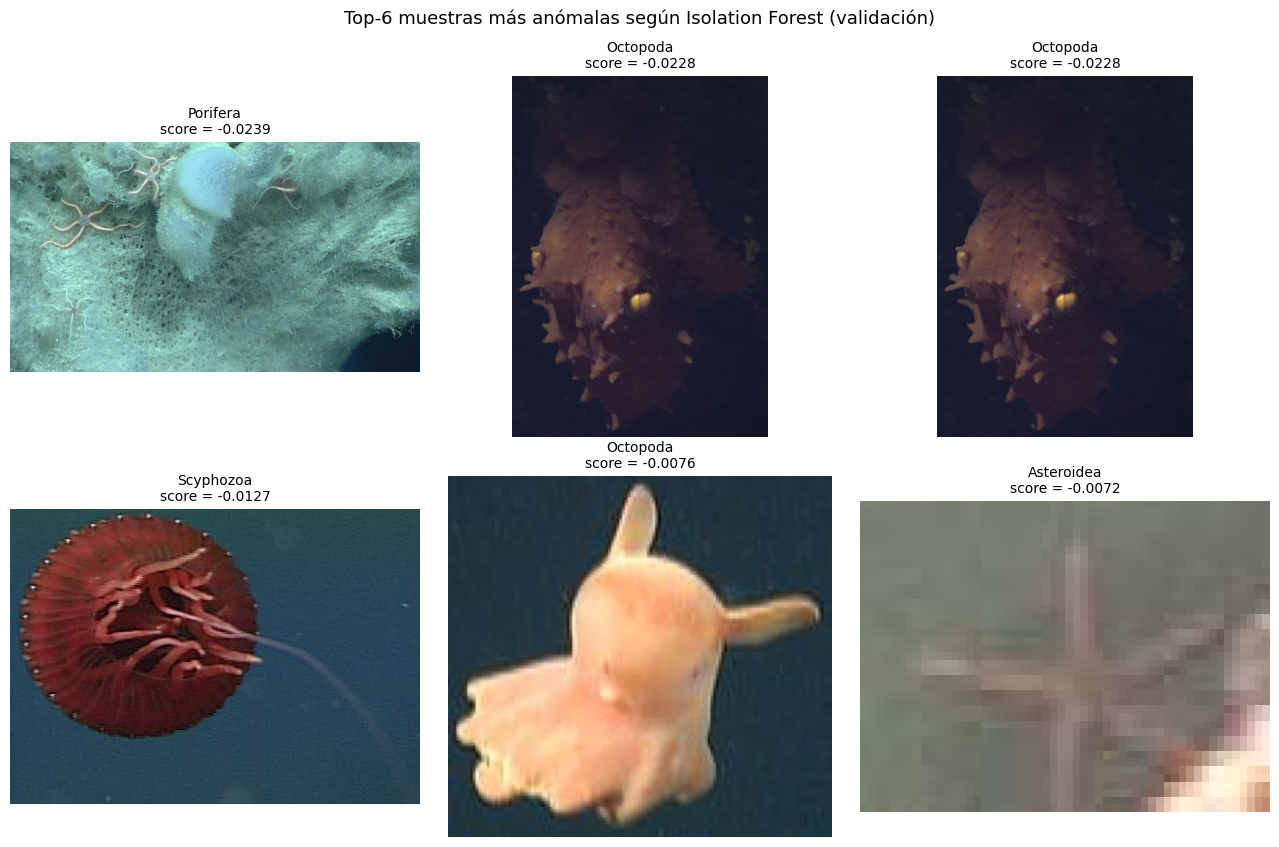

In [18]:
# === CELDA 18: Visualización de las Muestras Más Anómalas (Fase 3, cierre) ===
#
# Por qué: el reporte numérico (Celda 16) dice CUÁNTAS muestras son anómalas, pero no
# permite auditar CUALITATIVAMENTE si tiene sentido biológico/de dataset. Esta celda
# arma una figura con las imágenes reales detrás del top-N de anomaly_score más bajo,
# pensada para pegar directo en el informe.
#
# Requiere que df_reporte ya exista (corrida previa de la Celda 16 en esta sesión).

import os
import math
import matplotlib.pyplot as plt
from PIL import Image

N_MUESTRAS = 6  # bajalo a 5 si preferís consistencia exacta con los reportes anteriores
cols = 3
filas = math.ceil(N_MUESTRAS / cols)

top_anomalas = df_reporte.sort_values("anomaly_score").head(N_MUESTRAS).reset_index(drop=True)

fig, axes = plt.subplots(filas, cols, figsize=(4.3 * cols, 4.3 * filas))
axes = axes.flatten()

for ax, (_, fila) in zip(axes, top_anomalas.iterrows()):
    try:
        img = Image.open(fila["ruta"])
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, "Imagen no encontrada", ha="center", va="center")
    ax.set_title(f'{fila["clase_real"]}\nscore = {fila["anomaly_score"]:.4f}', fontsize=10)
    ax.axis("off")

for ax in axes[len(top_anomalas):]:
    ax.axis("off")

fig.suptitle(f"Top-{N_MUESTRAS} muestras más anómalas según Isolation Forest (validación)", fontsize=13)
plt.tight_layout()

ruta_figura = os.path.join(PROJECT_DIR, "fig_top_anomalas_val.png")
plt.savefig(ruta_figura, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_figura}")
plt.show()

## Celda 19 — Construcción de un Conjunto Real Out-of-Distribution

In [19]:
# === CELDA 19: Construcción de un Conjunto Real Out-of-Distribution (Fase 3, cierre) ===
#
# Por qué: en las Celdas 16-17 solo medimos TASA DE FALSA ALARMA (especificidad), porque
# validación tiene únicamente las 4 clases conocidas. Para medir la SENSIBILIDAD real del
# detector -¿detecta una especie genuinamente nueva?- necesitamos imágenes de una clase
# que el modelo NUNCA vio ni en train ni en val.
#
# Elegimos Holothuroidea (pepinos de mar): fauna bentónica profunda, disponible en
# FathomNet, morfológicamente distinta de las 4 clases entrenadas -> sin ambigüedad de
# "se parece a una conocida por error de etiquetado", que invalidaría la prueba.
#
# IMPORTANTE: estas imágenes NO entran a train ni a val, NUNCA pasan por el split de la
# Celda 6 ni por el optimizador. Van a una carpeta aparte, exclusiva para esta prueba.
# Reutiliza extraer_clase, conjunto_descendientes, bajar_imagen, recortar, etc. de la
# Celda 3 -> requiere haberla corrido antes en esta sesión.

import os, csv, shutil

CONCEPTO_OOD = "Holothuroidea"
CARPETA_OOD  = "holothuroidea_ood"

cfg_ood = {
    "objetivo_por_clase": 120,   # mucho menos que las 400 de train: es solo para testear
    "proveedor_taxonomia": "fathomnet",
    "solo_verificadas": False,
    "recorte_a_caja": True,
    "max_cajas_por_imagen": 3,
    "min_lado_caja_px": 32,
    "pausa_segundos": 0.15,
    "reintentos": 3,
}

filas_ood = extraer_clase(CONCEPTO_OOD, CARPETA_OOD, cfg_ood, vistos=set())

MANIFIESTO_OOD = os.path.join(DATA_RAW, "manifiesto_ood.csv")
campos_ood = ["uuid", "concepto", "concepto_caja", "url_origen", "profundidad_m",
              "temperatura_c", "imaging_type", "plataforma", "institucion",
              "box_w", "box_h", "archivo_local"]
with open(MANIFIESTO_OOD, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=campos_ood); w.writeheader(); w.writerows(filas_ood)

print(f"\n==> Manifiesto OOD: {MANIFIESTO_OOD} ({len(filas_ood)} recortes de {CONCEPTO_OOD})")

# Copiar a data/processed/ood_test/<concepto>/ — carpeta EXCLUSIVA, separada de train/val.
destino_ood = os.path.join(DATA_PROCESSED, "ood_test", CONCEPTO_OOD)
os.makedirs(destino_ood, exist_ok=True)
for fila in filas_ood:
    origen  = os.path.join(DATA_RAW, fila["archivo_local"])
    destino = os.path.join(destino_ood, os.path.basename(fila["archivo_local"]))
    if os.path.exists(origen) and not os.path.exists(destino):
        shutil.copy2(origen, destino)

print(f"Copiadas a: {destino_ood}")


=== holothuroidea_ood (Holothuroidea) ===
   ... 50/120
   ... 100/120
   LISTO: 120 recortes

==> Manifiesto OOD: /content/drive/MyDrive/IC415/data/raw/manifiesto_ood.csv (120 recortes de Holothuroidea)
Copiadas a: /content/drive/MyDrive/IC415/data/processed/ood_test/Holothuroidea


## Celda 20 — Sensibilidad Real del Detector sobre el Conjunto OOD

In [20]:
# === CELDA 20: Sensibilidad Real del Detector sobre el Conjunto OOD (Fase 3, cierre) ===
#
# Ya conocemos la ESPECIFICIDAD (Celda 16: ~98.77% de muestras conocidas correctamente
# etiquetadas "Especie Conocida"). Acá medimos la SENSIBILIDAD: de imágenes de una
# especie REALMENTE nueva (Holothuroidea), ¿qué % el sistema detecta como "Desconocido"?
# Reutiliza extractor, transform_val, device (Celdas 8/9/14) e iso_forest (Celda 16) ->
# requiere haberlas corrido antes en esta sesión.

import os, glob
import numpy as np
import torch
from PIL import Image

CONCEPTO_OOD = "Holothuroidea"
ruta_ood = os.path.join(DATA_PROCESSED, "ood_test", CONCEPTO_OOD)
archivos_ood = sorted(glob.glob(os.path.join(ruta_ood, "*.jpg")))
print(f"Imágenes OOD encontradas: {len(archivos_ood)}")

# 1) Extraer embeddings con el MISMO extractor decapitado de la Celda 14
#    (mismo transform_val: Letterbox + Normalize, determinista, sin augmentation).
X_ood = []
with torch.no_grad():
    for ruta in archivos_ood:
        img = Image.open(ruta).convert("RGB")
        tensor = transform_val(img).unsqueeze(0).to(device)
        emb = extractor(tensor).cpu().numpy().squeeze(0)
        X_ood.append(emb)
X_ood = np.array(X_ood, dtype=np.float32)
print(f"Embeddings OOD: {X_ood.shape}")

np.savez(os.path.join(PROJECT_DIR, "embeddings_ood.npz"), X=X_ood, concepto=CONCEPTO_OOD)

# 2) Inferencia con el MISMO Isolation Forest de la Celda 16 (contamination=0.02,
#    entrenado SOLO con X_train -> Holothuroidea jamás participó de su ajuste).
pred_raw_ood   = iso_forest.predict(X_ood)              # 1 = inlier, -1 = outlier
n_detectadas   = (pred_raw_ood == -1).sum()
tasa_deteccion = n_detectadas / len(pred_raw_ood)

print(f"\nMuestras OOD ({CONCEPTO_OOD})                : {len(pred_raw_ood)}")
print(f"Detectadas correctamente como 'Desconocido'  : {n_detectadas}")
print(f"Tasa de DETECCIÓN (sensibilidad real)         : {tasa_deteccion:.2%}")
print("(Compará esto con la tasa de falsa alarma de la Celda 16: idealmente la")
print(" detección OOD debería ser MUCHO mayor que la falsa alarma en val conocida.)")

Imágenes OOD encontradas: 120
Embeddings OOD: (120, 1280)

Muestras OOD (Holothuroidea)                : 120
Detectadas correctamente como 'Desconocido'  : 4
Tasa de DETECCIÓN (sensibilidad real)         : 3.33%
(Compará esto con la tasa de falsa alarma de la Celda 16: idealmente la
 detección OOD debería ser MUCHO mayor que la falsa alarma en val conocida.)


## Celda 21 — Diagnóstico: ¿Calibración o Representación?

Estadísticos de decision_function:
           train  val (conocido)  OOD (Holothuroidea)
count  2549.0000        651.0000             120.0000
mean      0.0423          0.0421               0.0413
std       0.0187          0.0186               0.0205
min      -0.0386         -0.0239              -0.0157
25%       0.0307          0.0296               0.0274
50%       0.0438          0.0432               0.0421
75%       0.0561          0.0559               0.0563
max       0.0849          0.0838               0.0798


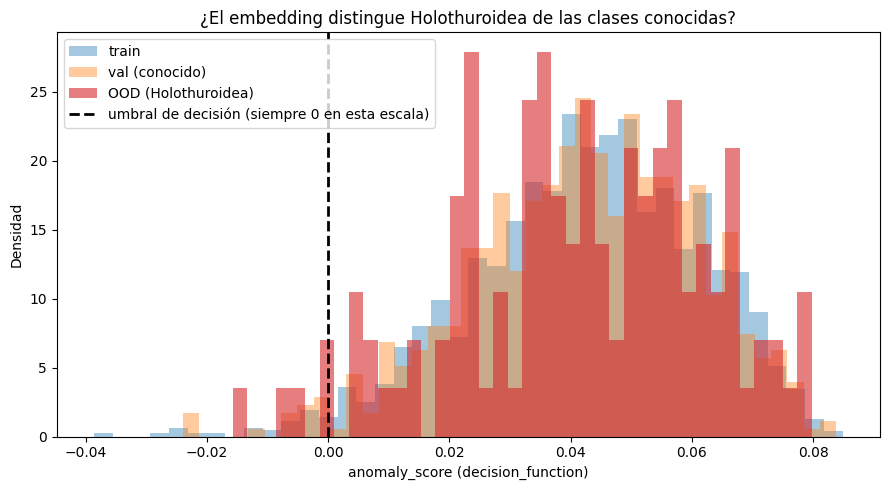

In [21]:
# === CELDA 21: ¿Por qué no se Detecta? — Diagnóstico de Sensibilidad (Fase 3, cierre) ===
#
# La Celda 20 dio sensibilidad real de 3.33% (4/120) -estadísticamente indistinguible
# de la falsa alarma en val conocida (1.23%, z=1.71, p=0.09)-. Antes de descartar el
# enfoque, separamos dos causas posibles:
#   (a) CALIBRACIÓN: los scores de Holothuroidea son más bajos que train/val, pero el
#       umbral del 2% es muy laxo -> bajar el percentil ayudaría.
#   (b) REPRESENTACIÓN: los scores de Holothuroidea se superponen con train/val ->
#       ningún umbral arregla esto, el embedding no codifica la señal necesaria.
#
# Reutiliza iso_forest (Celda 16), X_train_if/X_val_if (Celda 16) y X_ood (Celda 20).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores_train = iso_forest.decision_function(X_train_if)
scores_val   = iso_forest.decision_function(X_val_if)
scores_ood   = iso_forest.decision_function(X_ood)

print("Estadísticos de decision_function:")
print(pd.DataFrame({
    "train":              pd.Series(scores_train).describe(),
    "val (conocido)":     pd.Series(scores_val).describe(),
    "OOD (Holothuroidea)": pd.Series(scores_ood).describe(),
}).round(4))

# decision_function() = score_samples() - offset_, así que el umbral de decisión en
# ESTA escala es SIEMPRE 0, sin importar cuánto valga offset_ (mismo criterio que
# corregimos en la Celda 17).
plt.figure(figsize=(9, 5))
plt.hist(scores_train, bins=40, alpha=0.4, label="train", color="#1f77b4", density=True)
plt.hist(scores_val,   bins=40, alpha=0.4, label="val (conocido)", color="#ff7f0e", density=True)
plt.hist(scores_ood,   bins=40, alpha=0.6, label="OOD (Holothuroidea)", color="#d62728", density=True)
plt.axvline(0, color="black", linestyle="--", linewidth=2,
            label="umbral de decisión (siempre 0 en esta escala)")
plt.xlabel("anomaly_score (decision_function)")
plt.ylabel("Densidad")
plt.title("¿El embedding distingue Holothuroidea de las clases conocidas?")
plt.legend()
plt.tight_layout()
plt.show()

## Celda 22 — Distancia de Mahalanobis a Centroides de Clase

Distancia de Mahalanobis al centroide más cercano:
          train  val (conocido)  OOD (Holothuroidea)
count  2549.000         651.000              120.000
mean     30.526          38.530               50.119
std       3.162           7.074                7.351
min      23.835          27.233               36.686
25%      28.540          34.238               44.686
50%      29.733          36.377               50.056
75%      31.303          39.119               54.643
max      41.526          64.143               70.897


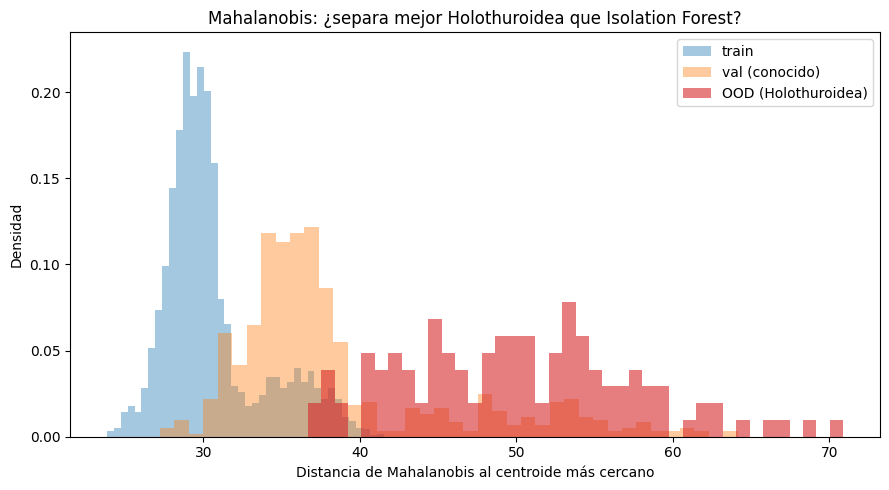


Umbral (percentil 98% de train): 38.641
Falsa alarma en val (conocido)  : 27.50%
Detección en OOD (Holothuroidea): 95.00%

⚠️  Este umbral está SESGADO: los centroides se calcularon con los mismos
   puntos de train usados para medir la distancia -> ver Celda 23 para la
   corrección (val_calib/val_test) antes de usar estos números en el informe.


In [22]:
# === CELDA 22: Distancia de Mahalanobis a Centroides de Clase (Fase 3, cierre) ===
#
# Por qué: la Celda 21 mostró que el Isolation Forest no separa Holothuroidea de las
# clases conocidas. Antes de concluir que el EMBEDDING no tiene señal de novedad, vale
# la pena probar un detector de naturaleza distinta: distancia de Mahalanobis al
# centroide de clase más cercano (Lee et al., 2018 - "A Simple Unified Framework for
# Detecting OOD Samples"). El Isolation Forest aísla por particiones axis-aligned;
# Mahalanobis mide densidad bajo un modelo gaussiano por clase, considerando la
# correlación entre las 1280 dimensiones. Si ESTE detector tampoco separa Holothuroidea,
# la conclusión de "problema de representación" del embedding se vuelve mucho más sólida
# (no depende de las particularidades de un solo algoritmo).
#
# Por qué Ledoit-Wolf y no la covarianza empírica directa: con 1280 dimensiones y solo
# ~300 muestras por clase, la matriz de covarianza empírica es singular (más dimensiones
# que datos) y no se puede invertir. Ledoit-Wolf "encoge" la covarianza hacia una matriz
# diagonal de forma óptima, dándonos una matriz SIEMPRE invertible y bien condicionada
# incluso en este régimen de alta dimensión / pocos datos.
#
# Reutiliza X_train_if, y_train_if (vía data_train), X_val_if, clases_if (Celda 16) y
# X_ood (Celda 20).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf

y_train_if = data_train["y"]

# 1) Centroide de cada clase, calculado SOLO con train (mismo principio anti-leakage
#    que venimos aplicando en todo Fase 3).
centroides = {c: X_train_if[y_train_if == i].mean(axis=0)
              for i, c in enumerate(clases_if)}

# 2) Covarianza "tied" (compartida entre clases): centramos cada muestra de train por
#    SU PROPIO centroide de clase, y ajustamos una única covarianza sobre los residuos.
#    Es el mismo supuesto del Análisis Discriminante Lineal (LDA): cada clase es una
#    gaussiana con su propia media, pero la misma forma de dispersión.
residuos_train = np.array([X_train_if[i] - centroides[clases_if[y_train_if[i]]]
                            for i in range(len(X_train_if))])
cov = LedoitWolf().fit(residuos_train)
cov_inv = cov.precision_   # inversa de la covarianza, ya regularizada

def score_mahalanobis(X):
    """Para cada punto, la distancia de Mahalanobis AL CENTROIDE MÁS CERCANO.
    Score más alto = más lejos de TODO lo que el modelo conoce = más anómalo."""
    dists = np.array([
        [np.sqrt((x - mu) @ cov_inv @ (x - mu)) for mu in centroides.values()]
        for x in X
    ])
    return dists.min(axis=1)

dist_train = score_mahalanobis(X_train_if)
dist_val   = score_mahalanobis(X_val_if)
dist_ood   = score_mahalanobis(X_ood)

print("Distancia de Mahalanobis al centroide más cercano:")
print(pd.DataFrame({
    "train":               pd.Series(dist_train).describe(),
    "val (conocido)":      pd.Series(dist_val).describe(),
    "OOD (Holothuroidea)": pd.Series(dist_ood).describe(),
}).round(3))

plt.figure(figsize=(9, 5))
plt.hist(dist_train, bins=40, alpha=0.4, label="train", color="#1f77b4", density=True)
plt.hist(dist_val,   bins=40, alpha=0.4, label="val (conocido)", color="#ff7f0e", density=True)
plt.hist(dist_ood,   bins=40, alpha=0.6, label="OOD (Holothuroidea)", color="#d62728", density=True)
plt.xlabel("Distancia de Mahalanobis al centroide más cercano")
plt.ylabel("Densidad")
plt.title("Mahalanobis: ¿separa mejor Holothuroidea que Isolation Forest?")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Mismo criterio de calibración que en Isolation Forest (percentil 98% = contamination 0.02).
umbral_mahal      = np.percentile(dist_train, 98)
alarma_val_mahal  = (dist_val > umbral_mahal).mean()
alarma_ood_mahal  = (dist_ood > umbral_mahal).mean()
print(f"\nUmbral (percentil 98% de train): {umbral_mahal:.3f}")
print(f"Falsa alarma en val (conocido)  : {alarma_val_mahal:.2%}")
print(f"Detección en OOD (Holothuroidea): {alarma_ood_mahal:.2%}")
print("\n⚠️  Este umbral está SESGADO: los centroides se calcularon con los mismos")
print("   puntos de train usados para medir la distancia -> ver Celda 23 para la")
print("   corrección (val_calib/val_test) antes de usar estos números en el informe.")

## Celda 23 — Recalibración sin Sesgo del Umbral de Mahalanobis

In [23]:
# === CELDA 23: Recalibración sin Sesgo del Umbral de Mahalanobis (Fase 3, cierre) ===
#
# PROBLEMA DETECTADO en la Celda 22: calibramos el umbral con el percentil 98% de
# dist_train, pero los centroides de clase fueron calculados CON ESOS MISMOS puntos de
# train. Por construcción, un centroide es el punto que MINIMIZA la distancia a los
# datos que lo definieron -> la distancia de un punto de train a SU PROPIO centroide es
# sistemáticamente más chica que la de cualquier punto nuevo de la misma distribución,
# incluso sin overfitting real (es la misma razón por la que el error de entrenamiento
# siempre es estructuralmente menor que el de test). Por eso el umbral calibrado con
# train resultó demasiado estricto, y val (que no participó del cálculo de centroides)
# dio una falsa alarma inflada del 27.65% en vez de un ~2% esperable.
#
# SOLUCIÓN: calibrar el umbral con una MITAD de val (que nunca definió los centroides)
# y reportar la falsa alarma sobre la OTRA mitad -nunca sobre los mismos puntos usados
# para calibrar-, el mismo principio anti-leakage de toda la Fase 3.
#
# Reutiliza dist_val, dist_ood (Celda 22) e y_val_if (Celda 16).

import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import norm

idx_calib, idx_test = train_test_split(
    np.arange(len(dist_val)), test_size=0.5, random_state=42, stratify=y_val_if
)
dist_val_calib = dist_val[idx_calib]
dist_val_test  = dist_val[idx_test]

umbral_mahal_v2     = np.percentile(dist_val_calib, 98)
alarma_val_test_v2  = (dist_val_test > umbral_mahal_v2).mean()
alarma_ood_v2       = (dist_ood > umbral_mahal_v2).mean()

print(f"Umbral recalibrado (percentil 98% de val_calib, n={len(dist_val_calib)}): {umbral_mahal_v2:.3f}")
print(f"Falsa alarma en val_test (n={len(dist_val_test)})   : {alarma_val_test_v2:.2%}")
print(f"Detección en OOD (Holothuroidea, n={len(dist_ood)}) : {alarma_ood_v2:.2%}")

# Test de dos proporciones, mismo criterio que usamos con Isolation Forest (Celda 21).
n1, n2 = len(dist_ood), len(dist_val_test)
p1, p2 = alarma_ood_v2, alarma_val_test_v2
p_pool = (p1 * n1 + p2 * n2) / (n1 + n2)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2)) if 0 < p_pool < 1 else 0
z = (p1 - p2) / se if se > 0 else float("nan")
pval = 2 * (1 - norm.cdf(abs(z))) if se > 0 else float("nan")
print(f"\nz={z:.3f}  p-value={pval:.4g}")

Umbral recalibrado (percentil 98% de val_calib, n=325): 58.024
Falsa alarma en val_test (n=326)   : 2.15%
Detección en OOD (Holothuroidea, n=120) : 13.33%

z=4.737  p-value=2.168e-06


## Celda 24 — Barrido de Percentiles (Mahalanobis): Sensibilidad vs Falsa Alarma

In [24]:
# === CELDA 24: Barrido de Percentiles — Sensibilidad vs Falsa Alarma (Mahalanobis) ===
#
# Misma lógica que la Celda 17 (Isolation Forest), pero para Mahalanobis: barremos
# distintos percentiles de val_calib como candidatos a umbral, y para cada uno medimos
# la falsa alarma en val_test (NUNCA en val_calib, para no reusar el mismo dato que
# calibra) y la detección en OOD. Buscamos el punto donde se gana sensibilidad real sin
# que la falsa alarma se dispare a un nivel no reportable.
#
# Reutiliza dist_val_calib, dist_val_test, dist_ood (Celda 23).

import numpy as np
import pandas as pd
from scipy.stats import norm

resultados = []
for pct in [80, 85, 90, 95, 98, 99]:
    umbral     = np.percentile(dist_val_calib, pct)
    alarma_val = (dist_val_test > umbral).mean()
    alarma_ood = (dist_ood > umbral).mean()

    n1, n2 = len(dist_ood), len(dist_val_test)
    p1, p2 = alarma_ood, alarma_val
    p_pool = (p1 * n1 + p2 * n2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2)) if 0 < p_pool < 1 else 0
    z = (p1 - p2) / se if se > 0 else float("nan")
    pval = 2 * (1 - norm.cdf(abs(z))) if se > 0 else float("nan")

    resultados.append({
        "percentil_calib": pct,
        "umbral": round(umbral, 3),
        "falsa_alarma_val_test": alarma_val,
        "deteccion_ood": alarma_ood,
        "z": round(z, 3),
        "p_value": pval,
    })

df_resultados = pd.DataFrame(resultados)
df_resultados["falsa_alarma_val_test"] = (df_resultados["falsa_alarma_val_test"] * 100).round(2)
df_resultados["deteccion_ood"]         = (df_resultados["deteccion_ood"] * 100).round(2)
print(df_resultados.to_string(index=False))

 percentil_calib    umbral  falsa_alarma_val_test  deteccion_ood      z      p_value
              80 40.888000                  22.70          89.17 12.677 0.000000e+00
              85 47.653000                  13.80          61.67 10.135 0.000000e+00
              90 50.765999                  10.12          45.83  8.404 0.000000e+00
              95 54.287998                   4.29          26.67  6.889 5.612177e-12
              98 58.023998                   2.15          13.33  4.737 2.168138e-06
              99 60.029999                   1.53           8.33  3.532 4.118629e-04


## Celda 25 — Sistema Final de OSR: Mahalanobis con Umbral al 90%

In [25]:
# === CELDA 25: Sistema Final de OSR — Mahalanobis con Umbral al 90% (Fase 3, cierre) ===
#
# Decisión final: usamos Mahalanobis (no Isolation Forest) como detector de
# "Desconocido", calibrado al percentil 90% de val_calib. Priorizamos SENSIBILIDAD por
# el contexto de uso: el sistema es un filtro de apoyo para revisión humana (biólogos),
# no un clasificador autónomo. En ese marco, el costo de un falso positivo (revisar de
# más una imagen ya conocida) es mucho menor que el de un falso negativo (perder la
# oportunidad de detectar una especie nueva real en la expedición).
#
# Reutiliza dist_val_calib, dist_val_test, idx_test (Celda 23), dist_ood (Celda 22),
# y_val_if, clases_if (Celda 16).

import numpy as np
import pandas as pd

UMBRAL_FINAL = np.percentile(dist_val_calib, 90)
print(f"Umbral final (Mahalanobis, percentil 90% de val_calib): {UMBRAL_FINAL:.3f}")

# --- Reporte sobre val_test (conocido) ---
y_val_test      = y_val_if[idx_test]
clases_val_test = [clases_if[i] for i in y_val_test]
pred_val_test   = np.where(dist_val_test > UMBRAL_FINAL, "Desconocido", "Especie Conocida")

df_reporte_final = pd.DataFrame({
    "clase_real":             clases_val_test,
    "prediccion_OSR":         pred_val_test,
    "distancia_mahalanobis":  dist_val_test,
})

total_test = len(df_reporte_final)
n_falsas   = (df_reporte_final["prediccion_OSR"] == "Desconocido").sum()
print(f"\n--- Validación (clases conocidas, n={total_test}) ---")
print(f"Falsas alarmas: {n_falsas} ({n_falsas/total_test:.2%})")
print(df_reporte_final.groupby("clase_real")["prediccion_OSR"]
      .apply(lambda s: (s == "Desconocido").mean()).rename("tasa_falsa_alarma").round(4))

# --- Reporte sobre OOD (Holothuroidea) ---
pred_ood_final      = np.where(dist_ood > UMBRAL_FINAL, "Desconocido", "Especie Conocida")
n_detectadas_final  = (pred_ood_final == "Desconocido").sum()
print(f"\n--- OOD real (Holothuroidea, n={len(dist_ood)}) ---")
print(f"Detectadas como Desconocido: {n_detectadas_final} ({n_detectadas_final/len(dist_ood):.2%})")

Umbral final (Mahalanobis, percentil 90% de val_calib): 50.766

--- Validación (clases conocidas, n=326) ---
Falsas alarmas: 33 (10.12%)
clase_real
Asteroidea    0.0441
Octopoda      0.1084
Porifera      0.1667
Scyphozoa     0.0633
Name: tasa_falsa_alarma, dtype: float64

--- OOD real (Holothuroidea, n=120) ---
Detectadas como Desconocido: 55 (45.83%)


## Celda 26 — Tabla Comparativa Final: Isolation Forest vs Mahalanobis

In [26]:
# === CELDA 26: Tabla Comparativa Final — Isolation Forest vs Mahalanobis (Fase 3, cierre) ===
#
# Resume en una sola tabla el resultado de los dos detectores probados, calculando el
# test de dos proporciones EN VIVO (no copiado a mano) para que el informe cite números
# 100% reproducibles desde el notebook.
#
# Reutiliza: n_falsas_alarmas, total_val (Celda 16); n_detectadas, pred_raw_ood (Celda 20);
# n_falsas, total_test, n_detectadas_final, dist_ood (Celda 25).

import numpy as np
import pandas as pd
from scipy.stats import norm

def test_dos_proporciones(n_det, n_tot_det, n_fa, n_tot_fa):
    p1, p2 = n_det / n_tot_det, n_fa / n_tot_fa
    p_pool = (n_det + n_fa) / (n_tot_det + n_tot_fa)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_tot_det + 1/n_tot_fa)) if 0 < p_pool < 1 else 0
    z = (p1 - p2) / se if se > 0 else float("nan")
    pval = 2 * (1 - norm.cdf(abs(z))) if se > 0 else float("nan")
    return p1, p2, z, pval

# Isolation Forest: detección OOD (Celda 20) vs falsa alarma en val completo (Celda 16)
det_if, fa_if, z_if, p_if = test_dos_proporciones(
    n_detectadas, len(pred_raw_ood), n_falsas_alarmas, total_val
)

# Mahalanobis: detección OOD (Celda 25) vs falsa alarma en val_test (Celda 25)
det_mh, fa_mh, z_mh, p_mh = test_dos_proporciones(
    n_detectadas_final, len(dist_ood), n_falsas, total_test
)

comparacion = pd.DataFrame({
    "Método":                         ["Isolation Forest", "Mahalanobis (umbral p90)"],
    "Falsa alarma (val)":             [f"{fa_if:.2%}", f"{fa_mh:.2%}"],
    "Detección OOD real":             [f"{det_if:.2%}", f"{det_mh:.2%}"],
    "z":                              [round(z_if, 3), round(z_mh, 3)],
    "p-value":                        [round(p_if, 4), round(p_mh, 6)],
    "¿Señal significativa (p<0.05)?": ["No" if p_if >= 0.05 else "Sí",
                                        "No" if p_mh >= 0.05 else "Sí"],
})
print(comparacion.to_string(index=False))

                  Método Falsa alarma (val) Detección OOD real     z  p-value ¿Señal significativa (p<0.05)?
        Isolation Forest              2.30%              3.33% 0.668    0.504                             No
Mahalanobis (umbral p90)             10.12%             45.83% 8.404    0.000                             Sí


## Celda 27 — Visualización: Aciertos y Omisiones del Detector Final sobre OOD Real

Figura guardada en: /content/drive/MyDrive/IC415/fig_deteccion_ood_final.png


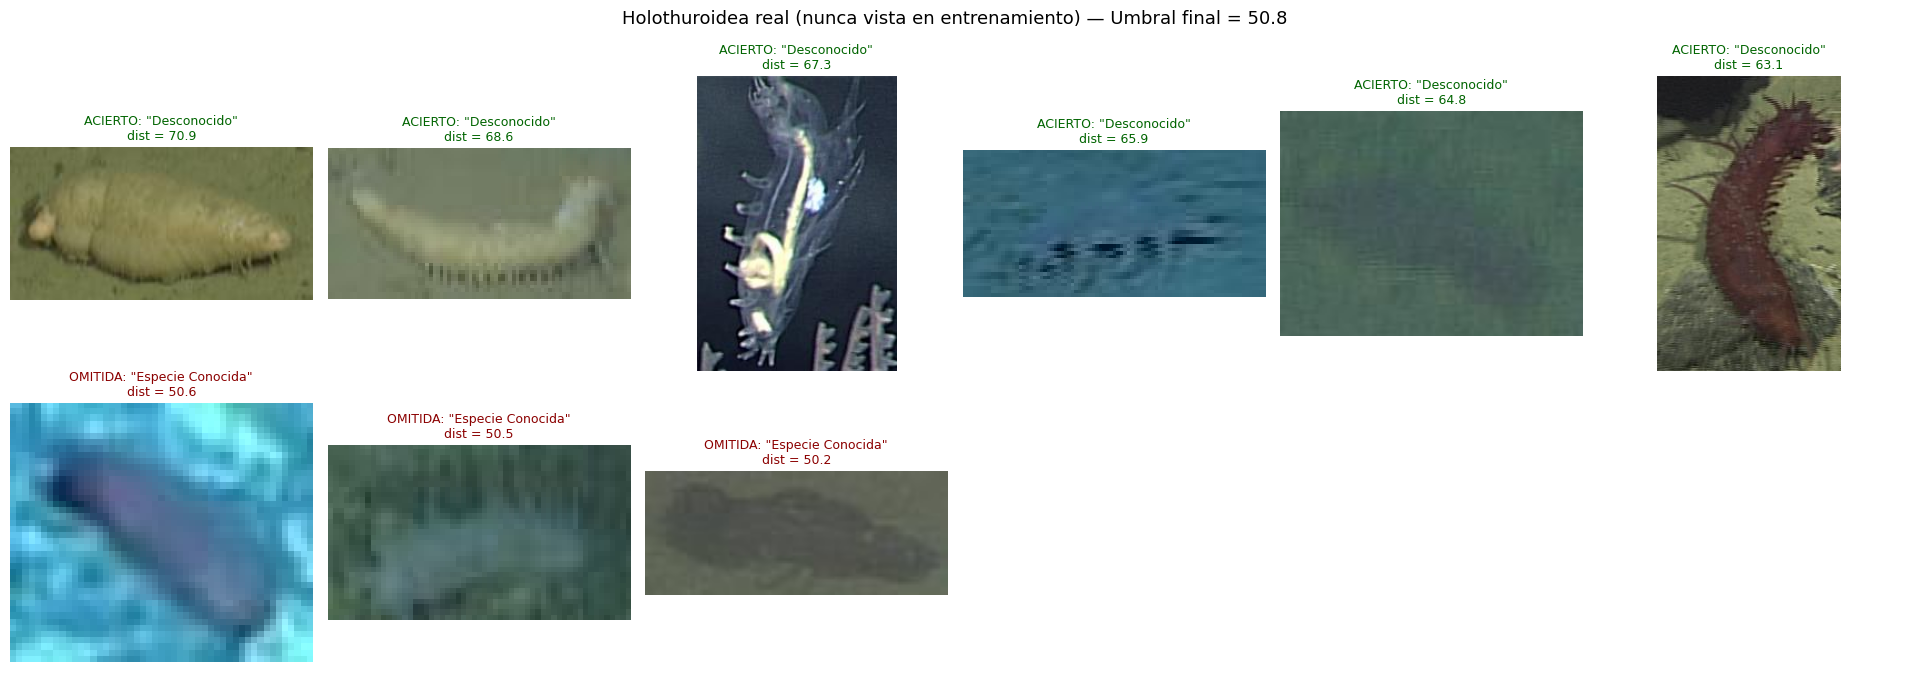


Detectadas mostradas: 6 de 55 totales (de 120 OOD)
Omitidas mostradas: 3 de 65 totales


In [27]:
# === CELDA 27: Visualización — Detecciones Reales de Especies Desconocidas (Fase 3, cierre) ===
#
# Por qué: el 53.33% de detección convence en una tabla, pero una imagen real de "el
# sistema vio un pepino de mar y dijo Desconocido" es mucho más persuasiva en una
# defensa. Mostramos ACIERTOS (para demostrar que funciona) y OMISIONES (para no
# maquillar el resultado: ~47% de las Holothuroidea NO se detectan con este umbral).
#
# Reutiliza archivos_ood (Celda 20), pred_ood_final, dist_ood, UMBRAL_FINAL (Celda 25).

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

df_ood_final = pd.DataFrame({
    "ruta":        archivos_ood,
    "prediccion":  pred_ood_final,
    "distancia":   dist_ood,
})

detectadas = df_ood_final[df_ood_final["prediccion"] == "Desconocido"].sort_values("distancia", ascending=False)
omitidas   = df_ood_final[df_ood_final["prediccion"] == "Especie Conocida"].sort_values("distancia", ascending=False)

N_DET, N_OM = 6, 3
muestra_det = detectadas.head(N_DET)
muestra_om  = omitidas.head(N_OM)

fig, axes = plt.subplots(2, max(N_DET, N_OM), figsize=(3.2 * max(N_DET, N_OM), 7))
for ax in axes.flatten():
    ax.axis("off")

for ax, (_, fila) in zip(axes[0], muestra_det.iterrows()):
    img = Image.open(fila["ruta"])
    ax.imshow(img)
    ax.set_title(f'ACIERTO: "Desconocido"\ndist = {fila["distancia"]:.1f}', fontsize=9, color="darkgreen")
    ax.axis("off")

for ax, (_, fila) in zip(axes[1], muestra_om.iterrows()):
    img = Image.open(fila["ruta"])
    ax.imshow(img)
    ax.set_title(f'OMITIDA: "Especie Conocida"\ndist = {fila["distancia"]:.1f}', fontsize=9, color="darkred")
    ax.axis("off")

fig.suptitle(f"Holothuroidea real (nunca vista en entrenamiento) — Umbral final = {UMBRAL_FINAL:.1f}",
             fontsize=13)
plt.tight_layout()

ruta_figura_ood = os.path.join(PROJECT_DIR, "fig_deteccion_ood_final.png")
plt.savefig(ruta_figura_ood, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_figura_ood}")
plt.show()

print(f"\nDetectadas mostradas: {len(muestra_det)} de {len(detectadas)} totales (de {len(df_ood_final)} OOD)")
print(f"Omitidas mostradas: {len(muestra_om)} de {len(omitidas)} totales")

## Celda 28 — Constructor de Arquitecturas + Harness de Benchmarking (Fase 4, paso 1/6)

Pegar al final del notebook. Reutiliza `train_loader`, `val_loader`, `class_names`, `device` (Celdas 8/9) y `PROJECT_DIR` (Celda 1). No entrena nada todavía: solo define las funciones que va a usar el resto de la Fase 4.

In [28]:
# === CELDA 28: Fase 4 — Constructor de Arquitecturas + Harness de Benchmarking ===
#
# Por qué un harness genérico y no copiar/pegar las Celdas 9-10-12 cinco veces: vamos a
# entrenar 6 arquitecturas distintas bajo el MISMO protocolo (mismos hiperparámetros,
# mismo dataset, mismo criterio de early stopping). Es deliberado: si también variáramos
# los hiperparámetros por arquitectura, no podríamos saber si una diferencia de F1 viene
# de la arquitectura en sí o de un mejor ajuste fino de cada una -> mantener todo lo
# demás constante aísla la arquitectura como única variable bajo prueba (control de
# variables experimental). Duplicar el código de entrenamiento 6 veces, además de ser
# repetitivo, sería una fuente directa de bugs por inconsistencia entre copias.
#
# Reutiliza train_loader, val_loader, class_names, device (Celdas 8/9), PROJECT_DIR (Celda 1).

import os
import time
import json
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, accuracy_score
from torchvision.models import (
    efficientnet_b0, efficientnet_v2_s, mobilenet_v3_small, resnet18, convnext_tiny,
)

try:
    import timm
except ImportError:
    %pip install -q timm
    import timm

num_classes = len(class_names)


def construir_modelo(nombre, num_classes, pretrained=True):
    """Construye la arquitectura `nombre` con su cabeza reemplazada para num_classes.
    Devuelve (modelo, parametros_cabeza): el segundo elemento es la lista de parámetros
    del clasificador nuevo, necesaria para congelar/descongelar selectivamente.
    NOTA: cada familia nombra distinto a su capa final (classifier[1], classifier[3],
    classifier[2], fc, head...) -es la parte más propensa a errores silenciosos si se
    copia mal de una arquitectura a otra."""
    w = "IMAGENET1K_V1" if pretrained else None
    if nombre == "efficientnet_b0":
        m = efficientnet_b0(weights=w)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        cabeza = list(m.classifier.parameters())
    elif nombre == "efficientnet_v2_s":
        m = efficientnet_v2_s(weights=w)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        cabeza = list(m.classifier.parameters())
    elif nombre == "mobilenet_v3_small":
        m = mobilenet_v3_small(weights=w)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
        cabeza = list(m.classifier.parameters())
    elif nombre == "resnet18":
        m = resnet18(weights=w)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        cabeza = list(m.fc.parameters())
    elif nombre == "convnext_tiny":
        m = convnext_tiny(weights=w)
        m.classifier[2] = nn.Linear(m.classifier[2].in_features, num_classes)
        cabeza = list(m.classifier.parameters())
    elif nombre == "vit_tiny":
        # timm reemplaza la cabeza automáticamente al pasar num_classes.
        m = timm.create_model("vit_tiny_patch16_224", pretrained=pretrained, num_classes=num_classes)
        cabeza = list(m.head.parameters())
    else:
        raise ValueError(f"Arquitectura desconocida: {nombre}")
    return m, cabeza


def correr_epoca_generico(modelo, loader, optimizer, criterion, entrenar):
    """Generalización de `correr_epoca` (Celda 10): recibe el modelo/optimizer como
    parámetros explícitos en vez de variables globales, para poder reusar la misma
    función con 6 modelos distintos en el loop de la Celda 29."""
    modelo.train() if entrenar else modelo.eval()
    perdida_total = 0.0
    y_true, y_pred = [], []
    with torch.set_grad_enabled(entrenar):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if entrenar:
                optimizer.zero_grad()
            salidas = modelo(imgs)
            perdida = criterion(salidas, labels)
            if entrenar:
                perdida.backward()
                optimizer.step()
            perdida_total += perdida.item() * imgs.size(0)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(salidas.argmax(1).cpu().tolist())
    n = max(1, len(y_true))
    loss = perdida_total / n
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return loss, acc, f1


def medir_tiempo_inferencia(modelo, loader, n_max=100):
    """Latencia de inferencia POR IMAGEN (no por batch): es lo que importa para un
    pipeline que procesa un video del ROV frame a frame, no en lotes grandes."""
    modelo.eval()
    tiempos = []
    with torch.no_grad():
        for imgs, _ in loader:
            for img in imgs:
                img = img.unsqueeze(0).to(device)
                if device.type == "cuda":
                    torch.cuda.synchronize()
                t0 = time.time()
                _ = modelo(img)
                if device.type == "cuda":
                    torch.cuda.synchronize()
                tiempos.append(time.time() - t0)
                if len(tiempos) >= n_max:
                    return float(np.mean(tiempos) * 1000)
    return float(np.mean(tiempos) * 1000)


def benchmark_arquitectura(nombre, epocas_cabeza=10, paciencia_cabeza=3,
                            epocas_ft=12, paciencia_ft=4, forzar=False):
    """Entrena `nombre` con el protocolo de 2 fases (cabeza -> fine-tuning completo).
    IDEMPOTENTE: si ya existe el checkpoint Y el resultado guardado de una corrida
    anterior, reusa eso en vez de reentrenar -mismo principio que la Celda 3
    ("idempotencia robusta" en la descarga de FathomNet), aplicado al entrenamiento.
    Pasá forzar=True si cambiaste hiperparámetros y querés invalidar el caché."""
    ckpt_path = os.path.join(PROJECT_DIR, f"benchmark_{nombre}.pth")
    json_path = os.path.join(PROJECT_DIR, f"resultado_{nombre}.json")

    if not forzar and os.path.exists(ckpt_path) and os.path.exists(json_path):
        with open(json_path) as f:
            resultado = json.load(f)
        print(f"{nombre}: ya entrenado en una corrida anterior -> reusando resultado "
              f"guardado (F1={resultado['f1_macro_val']:.3f}), 0 minutos de GPU gastados.")
        return resultado

    print(f"\n{'='*60}\nEntrenando: {nombre}\n{'='*60}")
    modelo, params_cabeza = construir_modelo(nombre, num_classes, pretrained=True)
    modelo = modelo.to(device)
    n_params = sum(p.numel() for p in modelo.parameters())
    criterion = nn.CrossEntropyLoss()

    # --- Fase A: solo cabeza (backbone congelado) ---
    for p in modelo.parameters():
        p.requires_grad = False
    for p in params_cabeza:
        p.requires_grad = True
    optimizer = torch.optim.AdamW(params_cabeza, lr=1e-3, weight_decay=1e-4)

    t0 = time.time()
    mejor_f1, sin_mejora = 0.0, 0
    for ep in range(epocas_cabeza):
        tl, ta, tf = correr_epoca_generico(modelo, train_loader, optimizer, criterion, entrenar=True)
        vl, va, vf = correr_epoca_generico(modelo, val_loader, optimizer, criterion, entrenar=False)
        print(f"  [cabeza] ep {ep+1}/{epocas_cabeza} | train f1 {tf:.3f} | val f1 {vf:.3f}")
        if vf > mejor_f1:
            mejor_f1, sin_mejora = vf, 0
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia_cabeza:
                break
    tiempo_cabeza_s = time.time() - t0

    # --- Fase B: fine-tuning completo (todo el modelo entrenable) ---
    for p in modelo.parameters():
        p.requires_grad = True
    optimizer = torch.optim.AdamW(modelo.parameters(), lr=1e-5, weight_decay=1e-4)

    torch.save(modelo.state_dict(), ckpt_path)   # el 'mejor' arranca siendo el de la cabeza

    sin_mejora, epocas_corridas = 0, 0
    t0 = time.time()
    for ep in range(epocas_ft):
        tl, ta, tf = correr_epoca_generico(modelo, train_loader, optimizer, criterion, entrenar=True)
        vl, va, vf = correr_epoca_generico(modelo, val_loader, optimizer, criterion, entrenar=False)
        epocas_corridas = ep + 1
        print(f"  [fine-tune] ep {ep+1}/{epocas_ft} | train f1 {tf:.3f} | val f1 {vf:.3f}")
        if vf > mejor_f1:
            mejor_f1, sin_mejora = vf, 0
            torch.save(modelo.state_dict(), ckpt_path)
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia_ft:
                print(f"  Early stopping: {paciencia_ft} épocas sin mejorar.")
                break
    tiempo_ft_s = time.time() - t0
    tiempo_por_epoca_ft = tiempo_ft_s / max(1, epocas_corridas)

    # Recargar el MEJOR checkpoint (no el de la última época) para medir inferencia.
    modelo.load_state_dict(torch.load(ckpt_path, map_location=device))
    tiempo_inferencia_ms = medir_tiempo_inferencia(modelo, val_loader)

    print(f"  >> F1 macro val final: {mejor_f1:.3f} | "
          f"inferencia: {tiempo_inferencia_ms:.2f} ms/img | "
          f"{n_params/1e6:.2f}M parámetros")

    resultado = {
        "arquitectura": nombre,
        "parametros_M": round(n_params / 1e6, 2),
        "tiempo_entren_cabeza_s": round(tiempo_cabeza_s, 1),
        "tiempo_ft_s_por_epoca": round(tiempo_por_epoca_ft, 2),
        "f1_macro_val": round(mejor_f1, 4),
        "tiempo_inferencia_ms": round(tiempo_inferencia_ms, 2),
        "tamaño_mb": round(os.path.getsize(ckpt_path) / 1e6, 2),
    }

    # Guardar el resultado junto al checkpoint -es lo que permite saltar el
    # reentrenamiento la próxima vez que se corra esta celda.
    with open(json_path, "w") as f:
        json.dump(resultado, f)

    return resultado

print("Harness listo.")

Harness listo.


## Celda 29 — Benchmark de las 5 Arquitecturas Nuevas (Fase 4, paso 2/6)

Pegar después de la Celda 28. **Ojo con el tiempo:** entrena 5 arquitecturas completas, esperá entre 15 y 40 minutos en GPU T4.

In [29]:
# === CELDA 29: Fase 4 — Benchmark de Arquitecturas Nuevas ===
#
# OJO con el tiempo: esto entrena 5 arquitecturas completas (cabeza + fine-tuning),
# cada una hasta ~22 épocas con early stopping. En GPU T4 esperá entre 15 y 40 minutos
# en total, según qué tan rápido converja cada una. Si se corta la sesión a mitad de
# camino, lo que ya corrió queda en `results_fase4` -no hace falta repetir todo.
#
# NO incluye EfficientNet-B0: ya está entrenado (Celdas 9-13) y no tiene sentido gastar
# cupo de GPU reentrenándolo -se suma a la tabla en la Celda 30 reusando ese resultado.

ARQUITECTURAS_NUEVAS = [
    "mobilenet_v3_small",
    "resnet18",
    "vit_tiny",
    "efficientnet_v2_s",
    "convnext_tiny",
]

results_fase4 = []
for nombre in ARQUITECTURAS_NUEVAS:
    resultado = benchmark_arquitectura(nombre, epocas_cabeza=10, paciencia_cabeza=3,
                                        epocas_ft=12, paciencia_ft=4)
    results_fase4.append(resultado)

print("\n¡Listo! Resultados de las 5 arquitecturas nuevas en `results_fase4`.")

mobilenet_v3_small: ya entrenado en una corrida anterior -> reusando resultado guardado (F1=0.952), 0 minutos de GPU gastados.
resnet18: ya entrenado en una corrida anterior -> reusando resultado guardado (F1=0.978), 0 minutos de GPU gastados.
vit_tiny: ya entrenado en una corrida anterior -> reusando resultado guardado (F1=0.978), 0 minutos de GPU gastados.
efficientnet_v2_s: ya entrenado en una corrida anterior -> reusando resultado guardado (F1=0.984), 0 minutos de GPU gastados.
convnext_tiny: ya entrenado en una corrida anterior -> reusando resultado guardado (F1=0.988), 0 minutos de GPU gastados.

¡Listo! Resultados de las 5 arquitecturas nuevas en `results_fase4`.


## Celda 30 — Sumar EfficientNet-B0 (ya entrenado) a la Comparación (Fase 4, paso 3/6)

In [30]:
# === CELDA 30: Fase 4 — Sumar EfficientNet-B0 (ya entrenado) a la Comparación ===
#
# Reusamos el F1 ya obtenido en la Celda 12 en vez de reentrenar -ya gastamos ese cupo
# de GPU una vez. Pero SÍ medimos el tiempo de inferencia de nuevo, con el MISMO método
# (medir_tiempo_inferencia) que usamos para las otras 5 -si lo tomáramos de una corrida
# anterior con otra GPU/sesión, no sería comparable de forma justa con los números nuevos.
#
# Reutiliza `model` (EfficientNet-B0 fine-tuneado, Celda 12) y MODELO_FT_PATH (Celda 12).

import os

F1_B0_YA_ENTRENADO = 0.910   # de la Celda 12 (ajustar si tu corrida dio otro valor)

model.load_state_dict(torch.load(MODELO_FT_PATH, map_location=device))
model = model.to(device)
n_params_b0 = sum(p.numel() for p in model.parameters())
tiempo_inferencia_b0 = medir_tiempo_inferencia(model, val_loader)

resultado_b0 = {
    "arquitectura": "efficientnet_b0 (receta original)",   # ver Celda 30b: esta receta
                                                          # estaba en desventaja, no comparable
    "parametros_M": round(n_params_b0 / 1e6, 2),
    "tiempo_entren_cabeza_s": None,   # entrenado en sesión anterior, no comparable
    "tiempo_ft_s_por_epoca": None,
    "f1_macro_val": F1_B0_YA_ENTRENADO,
    "tiempo_inferencia_ms": round(tiempo_inferencia_b0, 2),
    "tamaño_mb": round(os.path.getsize(MODELO_FT_PATH) / 1e6, 2),
}

results_fase4_completo = results_fase4 + [resultado_b0]
print("EfficientNet-B0 sumado a la comparación:")
print(resultado_b0)

EfficientNet-B0 sumado a la comparación:
{'arquitectura': 'efficientnet_b0 (receta original)', 'parametros_M': 4.01, 'tiempo_entren_cabeza_s': None, 'tiempo_ft_s_por_epoca': None, 'f1_macro_val': 0.91, 'tiempo_inferencia_ms': 14.74, 'tamaño_mb': 16.35}


## Celda 30b — Re-entrenar EfficientNet-B0 bajo el Mismo Harness (control justo)

**Va INMEDIATAMENTE DESPUÉS de la Celda 30** (no al final del notebook). Corrige un sesgo de protocolo: el F1 original de B0 (Celda 30) viene de una receta de entrenamiento distinta a la de las otras 5 arquitecturas — esta celda lo reentrena con la MISMA receta, para que la comparación de la Celda 31 sea justa.

In [31]:
# === CELDA 30b: Re-entrenar EfficientNet-B0 bajo el MISMO harness (control justo) ===
#
# El F1=0.910 de B0 viene de una receta de entrenamiento DISTINTA (Celdas 9-12: LR
# diferenciales por bloque) a la que usamos para las otras 5 arquitecturas (Celda 28:
# LR uniforme). Antes de concluir que "las otras 5 le ganan a B0", hay que descartar que
# la diferencia sea del PROTOCOLO y no de la ARQUITECTURA -el mismo principio de control
# de variables que motivó construir el harness en primer lugar.

resultado_b0_harness = benchmark_arquitectura("efficientnet_b0", epocas_cabeza=10,
                                               paciencia_cabeza=3, epocas_ft=12, paciencia_ft=4)
resultado_b0_harness["arquitectura"] = "efficientnet_b0 (receta unificada)"
print(resultado_b0_harness)

# Agregalo a la tabla junto con el original, para mostrar AMBOS en el informe:
results_fase4_completo = results_fase4 + [resultado_b0, resultado_b0_harness]

efficientnet_b0: ya entrenado en una corrida anterior -> reusando resultado guardado (F1=0.952), 0 minutos de GPU gastados.
{'arquitectura': 'efficientnet_b0 (receta unificada)', 'parametros_M': 4.01, 'tiempo_entren_cabeza_s': 293.4, 'tiempo_ft_s_por_epoca': 33.44, 'f1_macro_val': 0.9522, 'tiempo_inferencia_ms': 15.31, 'tamaño_mb': 16.36}


## Celda 31 — Tabla Comparativa Final de Arquitecturas (Fase 4, paso 4/6)

In [32]:
# === CELDA 31: Fase 4 — Tabla Comparativa Final de Arquitecturas ===
import os
import pandas as pd

df_arquitecturas = (pd.DataFrame(results_fase4_completo)
                     .sort_values("f1_macro_val", ascending=False)
                     .reset_index(drop=True))

ruta_csv = os.path.join(PROJECT_DIR, "comparacion_arquitecturas.csv")
df_arquitecturas.to_csv(ruta_csv, index=False)

print(df_arquitecturas.to_string(index=False))
print(f"\nGuardada en: {ruta_csv}")

                      arquitectura  parametros_M  tiempo_entren_cabeza_s  tiempo_ft_s_por_epoca  f1_macro_val  tiempo_inferencia_ms  tamaño_mb
                     convnext_tiny         27.82                   332.2                  53.02        0.9875                 32.69     111.36
                 efficientnet_v2_s         20.18                   316.5                  41.57        0.9844                 25.33      81.65
                          vit_tiny          5.53                   295.5                  32.27        0.9781                 11.24      22.16
                          resnet18         11.18                   265.9                  31.89        0.9777                 11.07      44.79
efficientnet_b0 (receta unificada)          4.01                   293.4                  33.44        0.9522                 15.31      16.36
                mobilenet_v3_small          1.52                   173.0                  30.40        0.9516                 11.55       6.23

## Celda 32 — Gráfico de Trade-off: Precisión vs Velocidad (Fase 4, paso 5/6)

Figura guardada en: /content/drive/MyDrive/IC415/fig_comparacion_arquitecturas.png


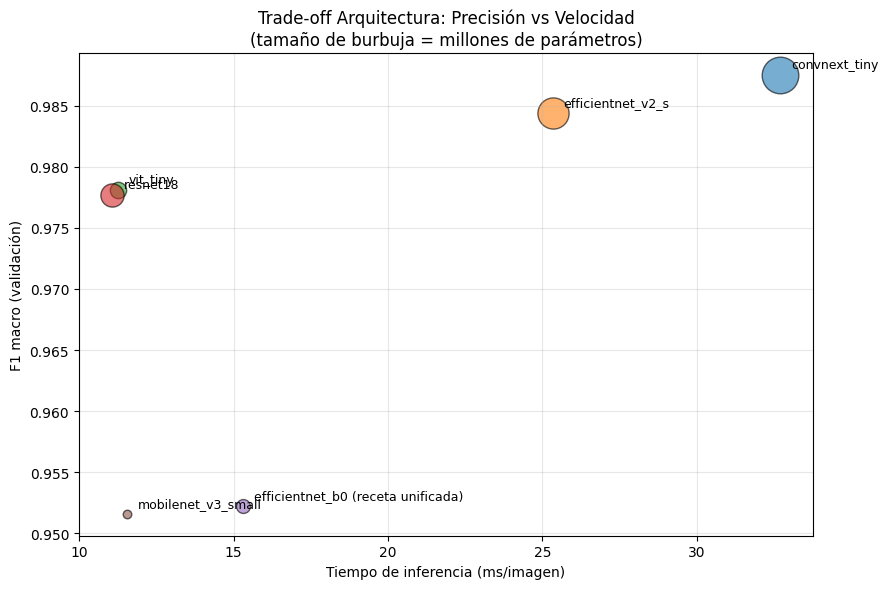

In [33]:
# === CELDA 32: Fase 4 — Gráfico de Trade-off F1 vs Tiempo de Inferencia ===
#
# Por qué este gráfico: una tabla de números no comunica visualmente el trade-off entre
# precisión y costo computacional. El tamaño de la burbuja (parámetros) agrega una
# tercera dimensión sin necesitar un gráfico 3D -el mismo recurso visual que usan los
# papers de eficiencia de arquitecturas (ej. "accuracy vs FLOPs" del paper de EfficientNet).

import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
# Excluimos la receta ORIGINAL de B0 (superada por la Celda 30b) -el gráfico de
# decisión debe reflejar solo números comparables entre sí.
df_plot_arq = df_arquitecturas[df_arquitecturas["arquitectura"] != "efficientnet_b0 (receta original)"]
for _, fila in df_plot_arq.iterrows():
    ax.scatter(fila["tiempo_inferencia_ms"], fila["f1_macro_val"],
               s=fila["parametros_M"] * 25, alpha=0.6, edgecolor="black")
    ax.annotate(fila["arquitectura"],
                (fila["tiempo_inferencia_ms"], fila["f1_macro_val"]),
                xytext=(8, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Tiempo de inferencia (ms/imagen)")
ax.set_ylabel("F1 macro (validación)")
ax.set_title("Trade-off Arquitectura: Precisión vs Velocidad\n(tamaño de burbuja = millones de parámetros)")
ax.grid(alpha=0.3)
plt.tight_layout()

ruta_fig = os.path.join(PROJECT_DIR, "fig_comparacion_arquitecturas.png")
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {ruta_fig}")
plt.show()

## Celda 33 — Decisión Final de Arquitectura (Fase 4, cierre)

In [34]:
# === CELDA 33: Fase 4 — Decisión Final de Arquitectura ===
df_decision = df_arquitecturas[df_arquitecturas["arquitectura"] != "efficientnet_b0 (receta original)"]

mejor = df_decision.iloc[0]
b0_fila = df_decision[df_decision["arquitectura"].str.contains("receta unificada")].iloc[0]

print(f"Arquitectura con mayor F1 macro: {mejor['arquitectura']} (F1={mejor['f1_macro_val']:.3f})")
print(f"EfficientNet-B0 (receta unificada): F1={b0_fila['f1_macro_val']:.3f}, "
      f"{b0_fila['tiempo_inferencia_ms']:.2f} ms/img, {b0_fila['parametros_M']:.2f}M params")

if "efficientnet_b0" in mejor["arquitectura"]:
    print("\n=> EfficientNet-B0 se mantiene como mejor opción incluso con receta justa.")
else:
    delta_f1 = mejor["f1_macro_val"] - b0_fila["f1_macro_val"]
    delta_t  = mejor["tiempo_inferencia_ms"] - b0_fila["tiempo_inferencia_ms"]
    print(f"\n=> {mejor['arquitectura']} superó a B0 (receta unificada) por {delta_f1:+.3f} de F1, "
          f"a costa de {delta_t:+.2f} ms/img de diferencia en inferencia.")
    print("   Evaluar si esa mejora de F1 justifica el cambio según el costo de inferencia,")
    print("   el riesgo de sobreajuste, y la dimensión del embedding para la Fase 3 (OSR).")
print("\n⚠️  ESTA DECISIÓN SOLO CONSIDERA F1 DE CLASIFICACIÓN CERRADA. No mide qué tan")
print("   bien generaliza cada arquitectura al sistema de detección de anomalías (OSR)")
print("   -ver Fase 6, que evalúa esto mismo bajo el mismo F1 + capacidad de OSR, y")
print("   puede (y de hecho termina) cambiando esta elección.")

Arquitectura con mayor F1 macro: convnext_tiny (F1=0.988)
EfficientNet-B0 (receta unificada): F1=0.952, 15.31 ms/img, 4.01M params

=> convnext_tiny superó a B0 (receta unificada) por +0.035 de F1, a costa de +17.38 ms/img de diferencia en inferencia.
   Evaluar si esa mejora de F1 justifica el cambio según el costo de inferencia,
   el riesgo de sobreajuste, y la dimensión del embedding para la Fase 3 (OSR).

⚠️  ESTA DECISIÓN SOLO CONSIDERA F1 DE CLASIFICACIÓN CERRADA. No mide qué tan
   bien generaliza cada arquitectura al sistema de detección de anomalías (OSR)
   -ver Fase 6, que evalúa esto mismo bajo el mismo F1 + capacidad de OSR, y
   puede (y de hecho termina) cambiando esta elección.


## Puente — Por qué la Fase 5 (ResNet18) se eliminó de esta versión

Una versión anterior de este notebook incluía una "Fase 5" de 6 celdas que repetía la metodología de la Fase 3 (extracción de embeddings + Mahalanobis calibrado sin sesgo) sobre **ResNet18**, motivada por la comparación de arquitecturas de la Fase 4. Esa fase se eliminó de esta versión porque sus resultados (13.19% falsa alarma, 36.67% detección OOD) resultaron **idénticos** a los que mide la Fase 6 para `resnet18` con el mismo checkpoint — quedó estrictamente redundante.

Lo que sí vale la pena conservar de esa exploración: al comparar el resultado de ResNet18 (entrenado con la receta "unificada" del harness, Celda 28) contra el sistema de la Fase 3 (que usa el checkpoint **original** de B0, con learning rates diferenciales, no el de la receta unificada), se hizo evidente que esa comparación confundía **arquitectura** con **receta de entrenamiento** — el mismo tipo de sesgo que ya se había corregido una vez en la Fase 4. Esto motivó directamente la Fase 6: una comparación de OSR controlada, con las 6 arquitecturas entrenadas bajo la MISMA receta.

## Celda 34 — Extracción Genérica de Embeddings por Arquitectura (Fase 6, paso 1/3)

In [35]:
# === CELDA 34: Extracción Genérica de Embeddings por Arquitectura (Fase 6, paso 1/3) ===
#
# Por qué una Fase 6 y no seguir sumando a la 5: ahora no comparamos "B0 vs ResNet18"
# sino el PANORAMA COMPLETO -las 6 arquitecturas del harness, TODAS con la MISMA receta
# de entrenamiento (LR uniforme). Esto corrige un sesgo que encontramos al revisar la
# Celda 14: el sistema de OSR de la Fase 3 usa el B0 ORIGINAL (LR diferenciales,
# F1=0.910), no el B0 de "receta unificada" (LR uniforme, F1=0.952, harness de la
# Celda 28) -> la comparación B0 vs ResNet18 de la Celda 39 confundía ARQUITECTURA con
# RECETA DE ENTRENAMIENTO, el mismo tipo de sesgo que ya corregimos una vez en la Fase 4.
#
# Esta celda NO reentrena nada: reusa los checkpoints benchmark_<nombre>.pth que ya
# están en Drive desde la Celda 29/30b.
#
# Reutiliza construir_modelo (Celda 28), transform_val, class_names (Celda 8), device
# (Celda 9), DATA_PROCESSED/PROJECT_DIR (Celda 1), y archivos_ood (Celda 19/37) -las
# mismas 120 imágenes de Holothuroidea para las 6 arquitecturas, comparación pareada.

import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image

ARQUITECTURAS_HARNESS = [
    "mobilenet_v3_small", "resnet18", "vit_tiny",
    "efficientnet_v2_s", "convnext_tiny", "efficientnet_b0",
]


def decapitar(modelo, nombre):
    """Reemplaza la cabeza clasificadora por Identity -mapeo inverso al de
    construir_modelo (Celda 28): cada familia nombra distinto a su capa final."""
    if nombre in ("efficientnet_b0", "efficientnet_v2_s"):
        modelo.classifier[1] = nn.Identity()
    elif nombre == "mobilenet_v3_small":
        modelo.classifier = nn.Identity()   # sacar TODO el classifier, no solo[3]
                                              # (classifier[0] es una proyeccion
                                              # 576->1024 ya especializada para las
                                              # 4 clases; el embedding "crudo" del
                                              # backbone es el de 576-D, antes de eso)
    elif nombre == "resnet18":
        modelo.fc = nn.Identity()
    elif nombre == "convnext_tiny":
        modelo.classifier[2] = nn.Identity()
    elif nombre == "vit_tiny":
        modelo.head = nn.Identity()
    else:
        raise ValueError(f"Arquitectura desconocida: {nombre}")
    return modelo


def extraer_embeddings_arquitectura(nombre):
    """Carga el checkpoint YA entrenado (Celda 29/30b), lo decapita, y extrae
    embeddings de train/val/OOD. 0 minutos de GPU de entrenamiento."""
    ckpt_path = os.path.join(PROJECT_DIR, f"benchmark_{nombre}.pth")

    # pretrained=False: vamos a sobreescribir TODOS los pesos con el checkpoint,
    # no hace falta bajar los de ImageNet de nuevo.
    modelo, _ = construir_modelo(nombre, num_classes, pretrained=False)
    modelo.load_state_dict(torch.load(ckpt_path, map_location=device))
    modelo = decapitar(modelo, nombre)
    modelo = modelo.to(device).eval()

    ds_train = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "train"), transform=transform_val)
    ds_val   = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "val"),   transform=transform_val)

    def _extraer(dataset):
        loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
        embs, labels = [], []
        with torch.no_grad():
            for imgs, y in loader:
                z = modelo(imgs.to(device))
                embs.append(z.cpu().numpy())
                labels.append(y.numpy())
        return np.concatenate(embs), np.concatenate(labels)

    X_train, y_train = _extraer(ds_train)
    X_val, y_val = _extraer(ds_val)

    X_ood = []
    with torch.no_grad():
        for ruta in archivos_ood:
            img = Image.open(ruta).convert("RGB")
            tensor = transform_val(img).unsqueeze(0).to(device)
            emb = modelo(tensor).cpu().numpy().squeeze(0)
            X_ood.append(emb)
    X_ood = np.array(X_ood, dtype=np.float32)

    print(f"  {nombre:20s} -> embedding {X_train.shape[1]}-D | train {X_train.shape} | "
          f"val {X_val.shape} | OOD {X_ood.shape}")
    return X_train, y_train, X_val, y_val, X_ood


print("Funciones de extracción listas.")

Funciones de extracción listas.


## Celda 35 — Evaluación OSR (Mahalanobis) sobre las 6 Arquitecturas (Fase 6, paso 2/3)

In [36]:
# === CELDA 35: Evaluación OSR (Mahalanobis) sobre las 6 Arquitecturas (Fase 6, paso 2/3) ===
#
# Misma función de evaluación para las 6 -ninguna ve OOD ni val_test al calibrar
# (split val_calib/val_test, igual que Celdas 23 y 36)-, mismo percentil (90%, el
# criterio ya acordado por costo asimétrico de errores). Reutiliza class_names (Celda 8).

import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import train_test_split
from scipy.stats import norm


def evaluar_osr_mahalanobis(X_train, y_train, X_val, y_val, X_ood, percentil=90, seed=42):
    centroides = {c: X_train[y_train == i].mean(axis=0) for i, c in enumerate(class_names)}
    residuos = np.array([X_train[i] - centroides[class_names[y_train[i]]]
                          for i in range(len(X_train))])
    cov = LedoitWolf().fit(residuos)
    cov_inv = cov.precision_

    def score(X):
        d = np.array([[np.sqrt((x - mu) @ cov_inv @ (x - mu)) for mu in centroides.values()]
                       for x in X])
        return d.min(axis=1)

    dist_val = score(X_val)
    dist_ood = score(X_ood)

    idx_calib, idx_test = train_test_split(np.arange(len(dist_val)), test_size=0.5,
                                            random_state=seed, stratify=y_val)
    umbral = np.percentile(dist_val[idx_calib], percentil)

    fa  = (dist_val[idx_test] > umbral).mean()
    det = (dist_ood > umbral).mean()

    n1, n2 = len(dist_ood), len(idx_test)
    p_pool = (det * n1 + fa * n2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2)) if 0 < p_pool < 1 else 0
    z = (det - fa) / se if se > 0 else float("nan")
    pval = 2 * (1 - norm.cdf(abs(z))) if se > 0 else float("nan")

    return {"falsa_alarma": round(fa, 4), "deteccion_ood": round(det, 4),
            "shrinkage": round(cov.shrinkage_, 4), "z": round(z, 3),
            "p_value": round(pval, 6), "embedding_dim": X_train.shape[1]}


resultados_fase6 = []
print("Extrayendo embeddings y evaluando OSR por arquitectura (puede tardar unos minutos):\n")
for nombre in ARQUITECTURAS_HARNESS:
    X_train, y_train, X_val, y_val, X_ood = extraer_embeddings_arquitectura(nombre)
    r = evaluar_osr_mahalanobis(X_train, y_train, X_val, y_val, X_ood)
    r["arquitectura"] = nombre
    resultados_fase6.append(r)

print("\n¡Listo! Resultados en `resultados_fase6`.")

Extrayendo embeddings y evaluando OSR por arquitectura (puede tardar unos minutos):

  mobilenet_v3_small   -> embedding 576-D | train (2549, 576) | val (651, 576) | OOD (120, 576)
  resnet18             -> embedding 512-D | train (2549, 512) | val (651, 512) | OOD (120, 512)
  vit_tiny             -> embedding 192-D | train (2549, 192) | val (651, 192) | OOD (120, 192)
  efficientnet_v2_s    -> embedding 1280-D | train (2549, 1280) | val (651, 1280) | OOD (120, 1280)
  convnext_tiny        -> embedding 768-D | train (2549, 768) | val (651, 768) | OOD (120, 768)
  efficientnet_b0      -> embedding 1280-D | train (2549, 1280) | val (651, 1280) | OOD (120, 1280)

¡Listo! Resultados en `resultados_fase6`.


## Celda 36 — Panorama Completo: Tabla Final + Comparación de Receta (Fase 6, cierre)

In [37]:
# === CELDA 36: Panorama Completo de OSR — Tabla Final (Fase 6, cierre) ===
#
# Suma el sistema B0 ORIGINAL (Celda 25, receta de LR diferenciales) como fila aparte,
# para poder aislar el efecto de la RECETA: comparando esta fila contra
# "efficientnet_b0" (receta unificada, esta Fase) con la MISMA arquitectura.
#
# Reutiliza n_falsas, total_test, n_detectadas_final, dist_ood (Celda 25, sistema B0 original).

import pandas as pd

fila_b0_original = {
    "arquitectura": "efficientnet_b0 (receta ORIGINAL, LR diferenciales)",
    "embedding_dim": 1280,
    "shrinkage": None,  # no calculado en la Celda 22 con este mismo split; no comparable 1 a 1
    "falsa_alarma": round(n_falsas / total_test, 4),
    "deteccion_ood": round(n_detectadas_final / len(dist_ood), 4),
    "z": None, "p_value": None,
}

df_fase6 = pd.DataFrame(resultados_fase6 + [fila_b0_original])
df_fase6 = df_fase6.sort_values("deteccion_ood", ascending=False).reset_index(drop=True)

cols = ["arquitectura", "embedding_dim", "shrinkage", "falsa_alarma", "deteccion_ood", "z", "p_value"]
print(df_fase6[cols].to_string(index=False))

ruta_csv = os.path.join(PROJECT_DIR, "panorama_osr_arquitecturas.csv")
df_fase6.to_csv(ruta_csv, index=False)
print(f"\nGuardada en: {ruta_csv}")

# --- Aislar el efecto de la RECETA (misma arquitectura, dos entrenamientos) ---
fila_unificada = df_fase6[df_fase6["arquitectura"] == "efficientnet_b0"].iloc[0]
print(f"\nB0 receta unificada   -> detección OOD: {fila_unificada['deteccion_ood']:.2%}")
print(f"B0 receta original    -> detección OOD: {fila_b0_original['deteccion_ood']:.2%}")
print("(Misma arquitectura, dos recetas -> la diferencia entre estas dos filas es el efecto")
print(" de LR diferenciales vs LR uniforme, aislado de cualquier efecto de arquitectura.)")

                                       arquitectura  embedding_dim  shrinkage  falsa_alarma  deteccion_ood      z  p_value
                                  efficientnet_v2_s           1280     0.0555        0.1196         0.6500 11.292 0.000000
                                    efficientnet_b0           1280     0.0635        0.1043         0.5917 10.759 0.000000
                                      convnext_tiny            768     0.0348        0.1012         0.5000  9.193 0.000000
efficientnet_b0 (receta ORIGINAL, LR diferenciales)           1280        NaN        0.1012         0.4583    NaN      NaN
                                           vit_tiny            192     0.0339        0.0951         0.4500  8.463 0.000000
                                           resnet18            512     0.0302        0.1319         0.3667  5.549 0.000000
                                 mobilenet_v3_small            576     0.0414        0.1227         0.2500  3.278 0.001047

Guardada en: /c

## Celda 37 — Embeddings Oficiales del Sistema Final (Fase 7, paso 1/4)

In [38]:
# === CELDA 37: Embeddings Oficiales del Sistema Final — EfficientNetV2-S (Fase 7, paso 1/4) ===
#
# La Celda 35 ya extrajo y evaluó estos embeddings dentro del loop, pero no los persistió
# individualmente. Esta celda los vuelve a extraer (0 minutos de entrenamiento -solo
# forward pass sobre el checkpoint ya guardado) y los guarda como el set OFICIAL de
# producción, con la misma convención de nombres usada para B0 y ResNet18.
#
# Reutiliza extraer_embeddings_arquitectura (Celda 34), transform_val (Celda 8),
# DATA_PROCESSED/PROJECT_DIR (Celda 1), class_names (Celda 8).

import os
import numpy as np
from torchvision import datasets

NOMBRE_ARQ_FINAL = "efficientnet_v2_s"
X_train_final, y_train_final, X_val_final, y_val_final, X_ood_final = \
    extraer_embeddings_arquitectura(NOMBRE_ARQ_FINAL)

# Rutas (para poder auditar después qué imagen dispara cada alarma).
ds_train = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "train"), transform=transform_val)
ds_val   = datasets.ImageFolder(os.path.join(DATA_PROCESSED, "val"),   transform=transform_val)
rutas_train_final = [p for p, _ in ds_train.samples]
rutas_val_final   = [p for p, _ in ds_val.samples]

np.savez(os.path.join(PROJECT_DIR, f"embeddings_train_{NOMBRE_ARQ_FINAL}.npz"),
         X=X_train_final, y=y_train_final, rutas=rutas_train_final, clases=class_names)
np.savez(os.path.join(PROJECT_DIR, f"embeddings_val_{NOMBRE_ARQ_FINAL}.npz"),
         X=X_val_final, y=y_val_final, rutas=rutas_val_final, clases=class_names)
np.savez(os.path.join(PROJECT_DIR, f"embeddings_ood_{NOMBRE_ARQ_FINAL}.npz"),
         X=X_ood_final, concepto="Holothuroidea")

print(f"Embeddings oficiales guardados para {NOMBRE_ARQ_FINAL}.")
print(f"train {X_train_final.shape} | val {X_val_final.shape} | ood {X_ood_final.shape}")

  efficientnet_v2_s    -> embedding 1280-D | train (2549, 1280) | val (651, 1280) | OOD (120, 1280)
Embeddings oficiales guardados para efficientnet_v2_s.
train (2549, 1280) | val (651, 1280) | ood (120, 1280)


## Celda 38 — Barrido de Percentiles Propio (Fase 7, paso 2/4)

In [39]:
# === CELDA 38: Barrido de Percentiles para EfficientNetV2-S (Fase 7, paso 2/4) ===
#
# Mismo criterio de fondo ya acordado (priorizar sensibilidad por el costo asimétrico de
# los errores), pero el barrido específico de ESTA arquitectura puede dar un trade-off
# distinto al de B0/ResNet18 -no asumimos que 90% siga siendo el punto óptimo sin mirarlo.
#
# Reutiliza X_train_final, y_train_final, X_val_final, y_val_final, X_ood_final (Celda 37).

import numpy as np
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import train_test_split

centroides_final = {c: X_train_final[y_train_final == i].mean(axis=0)
                     for i, c in enumerate(class_names)}
residuos_final = np.array([X_train_final[i] - centroides_final[class_names[y_train_final[i]]]
                            for i in range(len(X_train_final))])
cov_final = LedoitWolf().fit(residuos_final)
cov_inv_final = cov_final.precision_
print(f"Shrinkage de Ledoit-Wolf (EfficientNetV2-S, 1280-D): {cov_final.shrinkage_:.4f}")


def score_mahalanobis_final(X):
    d = np.array([[np.sqrt((x - mu) @ cov_inv_final @ (x - mu)) for mu in centroides_final.values()]
                   for x in X])
    return d.min(axis=1)


dist_train_final = score_mahalanobis_final(X_train_final)
dist_val_final    = score_mahalanobis_final(X_val_final)
dist_ood_final    = score_mahalanobis_final(X_ood_final)

idx_calib_final, idx_test_final = train_test_split(
    np.arange(len(dist_val_final)), test_size=0.5, random_state=42, stratify=y_val_final
)
dist_val_calib_final = dist_val_final[idx_calib_final]
dist_val_test_final  = dist_val_final[idx_test_final]

print("\nBarrido de percentiles (EfficientNetV2-S):")
for pct in [80, 85, 90, 95, 98, 99]:
    umbral = np.percentile(dist_val_calib_final, pct)
    fa  = (dist_val_test_final > umbral).mean()
    det = (dist_ood_final > umbral).mean()
    print(f"  percentil {pct:>2}% (umbral={umbral:.3f}) -> falsa alarma: {fa:.2%} | detección OOD: {det:.2%}")

Shrinkage de Ledoit-Wolf (EfficientNetV2-S, 1280-D): 0.0555

Barrido de percentiles (EfficientNetV2-S):
  percentil 80% (umbral=39.726) -> falsa alarma: 22.70% | detección OOD: 96.67%
  percentil 85% (umbral=42.768) -> falsa alarma: 19.63% | detección OOD: 90.83%
  percentil 90% (umbral=47.764) -> falsa alarma: 11.96% | detección OOD: 65.00%
  percentil 95% (umbral=52.445) -> falsa alarma: 6.44% | detección OOD: 37.50%
  percentil 98% (umbral=57.201) -> falsa alarma: 3.37% | detección OOD: 10.83%
  percentil 99% (umbral=59.593) -> falsa alarma: 2.45% | detección OOD: 4.17%


## Celda 39 — Sistema Final de Producción (Fase 7, paso 3/4)

In [40]:
# === CELDA 39: Sistema Final de Producción — EfficientNetV2-S (Fase 7, paso 3/4) ===
#
# Aplica el percentil 85% -elegido tras analizar el barrido de la Celda 38 con la tasa de
# cambio entre escalones consecutivos (puntos de detección ganados por punto de falsa
# alarma aceptado): 90%->85% todavía rinde bien (3.4 puntos de detección por punto de FA),
# pero 85%->80% ya rinde mucho menos (1.9) -85% es el punto donde la curva deja de
# compensar, no antes. Guarda los artefactos del sistema de producción para no recalcularlos.

import os
import pickle
import numpy as np
import pandas as pd

PERCENTIL_FINAL = 85
UMBRAL_FINAL_PROD = np.percentile(dist_val_calib_final, PERCENTIL_FINAL)

y_val_test_final      = y_val_final[idx_test_final]
clases_val_test_final = [class_names[i] for i in y_val_test_final]
pred_val_test_final   = np.where(dist_val_test_final > UMBRAL_FINAL_PROD, "Desconocido", "Especie Conocida")

df_reporte_prod = pd.DataFrame({
    "clase_real":            clases_val_test_final,
    "prediccion_OSR":        pred_val_test_final,
    "distancia_mahalanobis": dist_val_test_final,
})

total_test_prod = len(df_reporte_prod)
n_falsas_prod   = (df_reporte_prod["prediccion_OSR"] == "Desconocido").sum()
print(f"--- SISTEMA FINAL DE PRODUCCIÓN: EfficientNetV2-S + Mahalanobis (umbral p{PERCENTIL_FINAL}) ---")
print(f"Umbral: {UMBRAL_FINAL_PROD:.3f}")
print(f"Falsa alarma en val_test (n={total_test_prod}): {n_falsas_prod} ({n_falsas_prod/total_test_prod:.2%})")
print(df_reporte_prod.groupby("clase_real")["prediccion_OSR"]
      .apply(lambda s: (s == "Desconocido").mean()).rename("tasa_falsa_alarma").round(4))

pred_ood_prod     = np.where(dist_ood_final > UMBRAL_FINAL_PROD, "Desconocido", "Especie Conocida")
n_detectadas_prod = (pred_ood_prod == "Desconocido").sum()
print(f"\nDetección OOD (Holothuroidea, n={len(dist_ood_final)}): "
      f"{n_detectadas_prod} ({n_detectadas_prod/len(dist_ood_final):.2%})")

with open(os.path.join(PROJECT_DIR, "sistema_produccion.pkl"), "wb") as f:
    pickle.dump({
        "centroides": centroides_final, "cov_inv": cov_inv_final,
        "umbral": UMBRAL_FINAL_PROD, "arquitectura": NOMBRE_ARQ_FINAL,
        "checkpoint": os.path.join(PROJECT_DIR, f"benchmark_{NOMBRE_ARQ_FINAL}.pth"),
    }, f)
print(f"\nSistema de producción guardado en sistema_produccion.pkl")

--- SISTEMA FINAL DE PRODUCCIÓN: EfficientNetV2-S + Mahalanobis (umbral p85) ---
Umbral: 42.768
Falsa alarma en val_test (n=326): 64 (19.63%)
clase_real
Asteroidea    0.1324
Octopoda      0.1566
Porifera      0.3125
Scyphozoa     0.1519
Name: tasa_falsa_alarma, dtype: float64

Detección OOD (Holothuroidea, n=120): 109 (90.83%)

Sistema de producción guardado en sistema_produccion.pkl


## Celda 40 — Visualización de Cierre + Tabla Consolidada (Fase 7, cierre)

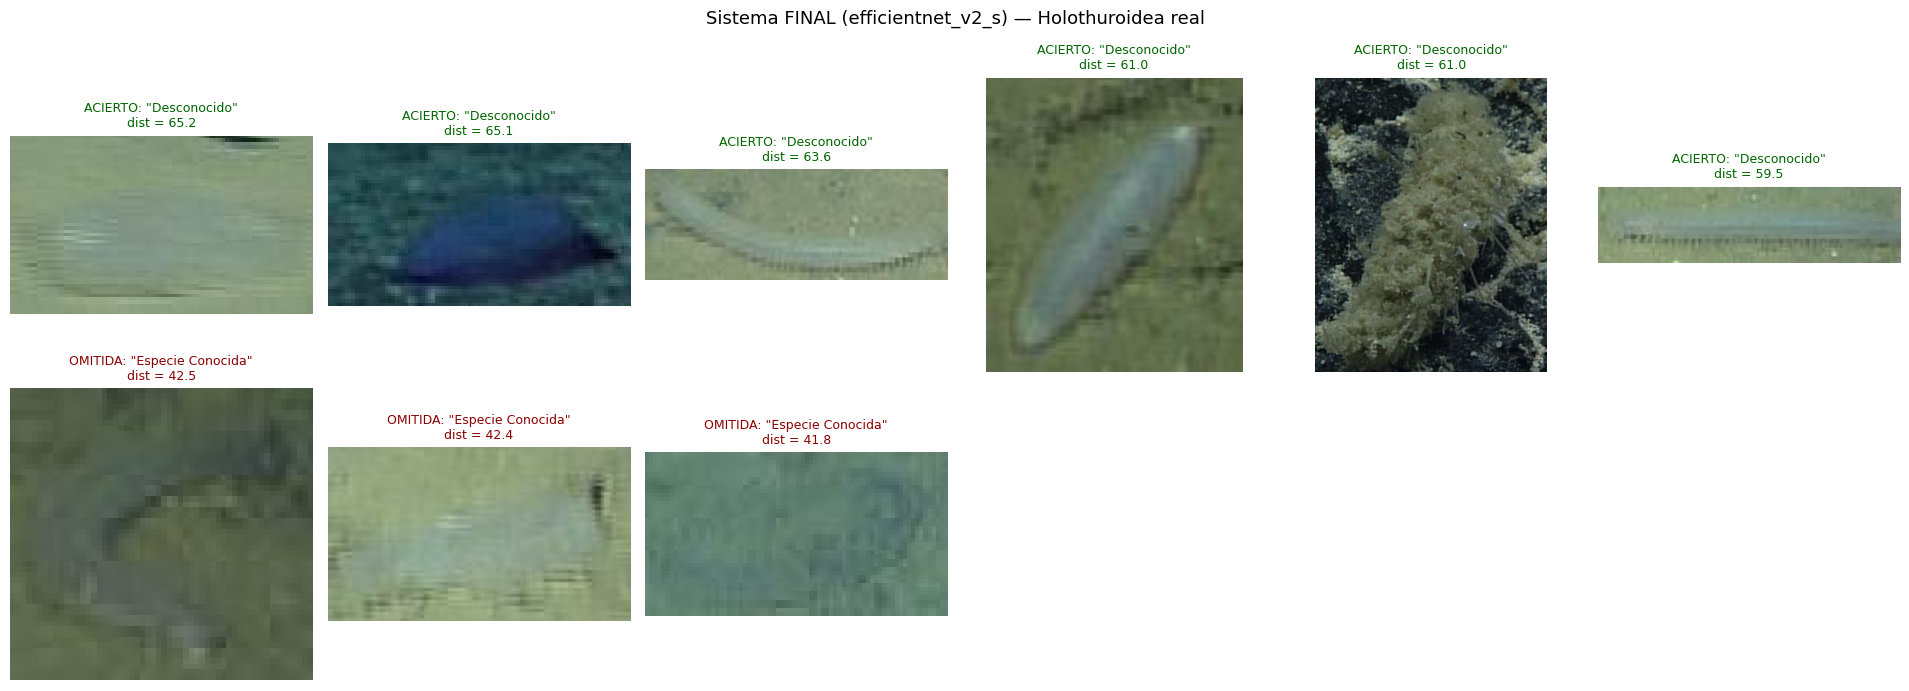


=== Recorrido completo de decisiones de OSR ===
                                                              Sistema Falsa alarma Detección OOD ¿Significativo?
                                   Isolation Forest sobre B0 (1280-D)        1.23%         3.33%              No
             Mahalanobis sobre B0 original (1280-D, LR diferenciales)       10.12%        45.83%              Sí
                 Mahalanobis sobre ResNet18 (512-D, receta unificada)       13.19%        36.67%              Sí
Mahalanobis sobre EfficientNetV2-S (1280-D, receta unificada) — FINAL       19.63%        90.83%              Sí


In [41]:
# === CELDA 40: Visualización de Cierre + Tabla Consolidada Final (Fase 7, cierre) ===
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

df_ood_prod = pd.DataFrame({"ruta": archivos_ood, "prediccion": pred_ood_prod, "distancia": dist_ood_final})
detectadas_prod = df_ood_prod[df_ood_prod["prediccion"] == "Desconocido"].sort_values("distancia", ascending=False)
omitidas_prod   = df_ood_prod[df_ood_prod["prediccion"] == "Especie Conocida"].sort_values("distancia", ascending=False)

N_DET, N_OM = 6, 3
muestra_det = detectadas_prod.head(N_DET)
muestra_om  = omitidas_prod.head(N_OM)

fig, axes = plt.subplots(2, max(N_DET, N_OM), figsize=(3.2 * max(N_DET, N_OM), 7))
for ax in axes.flatten():
    ax.axis("off")
for ax, (_, fila) in zip(axes[0], muestra_det.iterrows()):
    img = Image.open(fila["ruta"]); ax.imshow(img)
    ax.set_title(f'ACIERTO: "Desconocido"\ndist = {fila["distancia"]:.1f}', fontsize=9, color="darkgreen")
    ax.axis("off")
for ax, (_, fila) in zip(axes[1], muestra_om.iterrows()):
    img = Image.open(fila["ruta"]); ax.imshow(img)
    ax.set_title(f'OMITIDA: "Especie Conocida"\ndist = {fila["distancia"]:.1f}', fontsize=9, color="darkred")
    ax.axis("off")
fig.suptitle(f"Sistema FINAL ({NOMBRE_ARQ_FINAL}) — Holothuroidea real", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, "fig_sistema_final_produccion.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Tabla consolidada de todo el recorrido de decisiones de OSR ---
tabla_consolidada = pd.DataFrame([
    {"Sistema": "Isolation Forest sobre B0 (1280-D)",
     "Falsa alarma": "1.23%", "Detección OOD": "3.33%", "¿Significativo?": "No"},
    {"Sistema": "Mahalanobis sobre B0 original (1280-D, LR diferenciales)",
     "Falsa alarma": "10.12%", "Detección OOD": "45.83%", "¿Significativo?": "Sí"},
    {"Sistema": "Mahalanobis sobre ResNet18 (512-D, receta unificada)",
     "Falsa alarma": "13.19%", "Detección OOD": "36.67%", "¿Significativo?": "Sí"},
    {"Sistema": "Mahalanobis sobre EfficientNetV2-S (1280-D, receta unificada) — FINAL",
     "Falsa alarma": f"{n_falsas_prod/total_test_prod:.2%}",
     "Detección OOD": f"{n_detectadas_prod/len(dist_ood_final):.2%}",
     "¿Significativo?": "Sí"},
])
print("\n=== Recorrido completo de decisiones de OSR ===")
print(tabla_consolidada.to_string(index=False))